# Final Training and Model Comparison — FER-2013

This notebook contains the final model training and comparison work for the FER-2013 emotion recognition project. It keeps the baseline CNN, ResNet-18, EfficientNet-B0, ConvNeXt-Tiny, cleaned-data runs, test-time augmentation, and ensemble evaluations used in the final report.


## 1. Setup and Imports


### Path Configuration

Set `BASE_DIR` to your Google Drive project folder.
Outputs (checkpoints, figures, metrics) all go under `BASE_DIR/outputs/`.


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os

# base path
BASE_DIR = Path('/content/drive/MyDrive/emotion_project')

# make dirs
BASE_DIR.mkdir(parents=True, exist_ok=True)

# output dirs
OUTPUTS_DIR = BASE_DIR / 'outputs'
CHECKPOINT_DIR = OUTPUTS_DIR / 'checkpoints'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
METRICS_DIR = OUTPUTS_DIR / 'metrics'

for folder in [OUTPUTS_DIR, CHECKPOINT_DIR, FIGURES_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/emotion_project
OUTPUTS_DIR: /content/drive/MyDrive/emotion_project/outputs


In [ ]:
# Install packages and download data
!pip -q install kagglehub

import kagglehub
from pathlib import Path

LOCAL_DATA_ROOT = Path('/content/data')
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

download_path = kagglehub.dataset_download(
    "msambare/fer2013",
    output_dir=str(LOCAL_DATA_ROOT)
)

DATA_DIR = Path(download_path)

# unwrap if nested
if not (DATA_DIR / 'train').exists() and not (DATA_DIR / 'test').exists():
    subdirs = [p for p in DATA_DIR.iterdir() if p.is_dir()]
    if len(subdirs) == 1:
        DATA_DIR = subdirs[0]

print("DATA_DIR:", DATA_DIR)
print("Contents:", sorted([p.name for p in DATA_DIR.iterdir()])[:20])

Using Colab cache for faster access to the 'fer2013' dataset.
DATA_DIR: /kaggle/input/fer2013
Contents: ['test', 'train']


In [ ]:
# Imports
import os
import json
import random
import warnings
from pathlib import Path
from collections import Counter
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings('ignore')

# fix random seed
def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# pick device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

# batch size config
BASELINE_BS = 128
TL_BS = 64
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA version: 12.8


## 2. Dataset Loading

FER-2013 uses the standard ImageFolder layout:

```
data/fer2013/
├── train/   ← 28 709 images
└── test/    ← 7 178 images
```

No `val/` folder was found, so we split 20 % of training for validation (≈ 5 742 images).


In [ ]:
# Find dataset folders
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

def discover_dataset(data_dir):
    """Inspect the dataset folder structure and report what we find."""
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(
            f"\n{'='*60}\n"
            f"  Dataset NOT found at:\n"
            f"    {data_dir.resolve()}\n\n"
            f"  Please download FER-2013 and organize it as:\n"
            f"    {data_dir}/train/<emotion>/*.jpg\n"
            f"    {data_dir}/test/<emotion>/*.jpg\n"
            f"    {data_dir}/val/<emotion>/*.jpg   (optional)\n"
            f"{'='*60}"
        )

    splits = {}
    for name in ['train', 'test', 'val', 'validation']:
        sp = data_dir / name
        if sp.is_dir():
            classes = sorted([d.name for d in sp.iterdir() if d.is_dir()])
            counts = {
                c: len([f for f in (sp / c).iterdir()
                        if f.suffix.lower() in IMAGE_EXTS])
                for c in classes
            }
            key = 'val' if name == 'validation' else name
            splits[key] = {'path': sp, 'classes': classes, 'counts': counts}

    if not splits or 'train' not in splits:
        raise FileNotFoundError(
            f"\n{'='*60}\n"
            f"  Expected at least a 'train/' folder inside:\n"
            f"    {data_dir.resolve()}\n"
            f"{'='*60}"
        )

    return splits

# discover splits
splits_info = discover_dataset(DATA_DIR)

print("Detected dataset structure:")
for name, info in splits_info.items():
    total = sum(info['counts'].values())
    print(f"  {name:>5s}: {total:>6d} images  |  {len(info['classes'])} classes")

CLASS_NAMES = splits_info['train']['classes']
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

HAS_VAL = 'val' in splits_info
if not HAS_VAL:
    print("\n⚠  No validation split detected — will create one from training data (80/20).")

Detected dataset structure:
  train:  28709 images  |  7 classes
   test:   7178 images  |  7 classes

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

⚠  No validation split detected — will create one from training data (80/20).


## 3. EDA and Class Distribution

FER-2013 is imbalanced — *Happy* makes up 25 % of training while *Disgust*
is only 1.5 %, giving a 16.5× imbalance ratio. We handle this with class-weighted
cross-entropy loss during training.


### Class Distribution

Bar chart of per-class counts in the training set.
Happy dominates; Disgust has far fewer examples — a clear long-tail pattern.


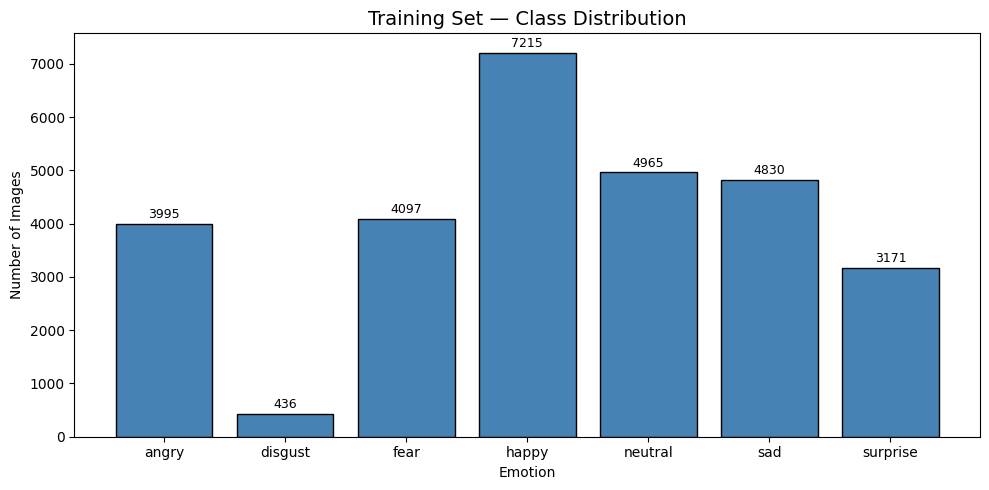

Class proportions:
       angry:  3995  (13.9%)
     disgust:   436  (1.5%)
        fear:  4097  (14.3%)
       happy:  7215  (25.1%)
     neutral:  4965  (17.3%)
         sad:  4830  (16.8%)
    surprise:  3171  (11.0%)

Imbalance ratio (max / min): 16.5x  (happy vs disgust)
→ Noticeable class imbalance — will use class-weighted loss during training.


In [ ]:
# Plot class distribution
train_counts = splits_info['train']['counts']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(train_counts.keys(), train_counts.values(),
              color='steelblue', edgecolor='black')
ax.set_title('Training Set — Class Distribution', fontsize=14)
ax.set_xlabel('Emotion')
ax.set_ylabel('Number of Images')

for bar, count in zip(bars, train_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution_train.png', dpi=150, bbox_inches='tight')
plt.show()

# imbalance ratio
total = sum(train_counts.values())
print("Class proportions:")
for cls, cnt in train_counts.items():
    print(f"  {cls:>10s}: {cnt:>5d}  ({100 * cnt / total:.1f}%)")

min_cls = min(train_counts, key=train_counts.get)
max_cls = max(train_counts, key=train_counts.get)
ratio = train_counts[max_cls] / train_counts[min_cls]
print(f"\nImbalance ratio (max / min): {ratio:.1f}x  ({max_cls} vs {min_cls})")
if ratio > 3:
    print("→ Noticeable class imbalance — will use class-weighted loss during training.")

### Sample Images

Sample images from each class — all grayscale, 48×48 px.


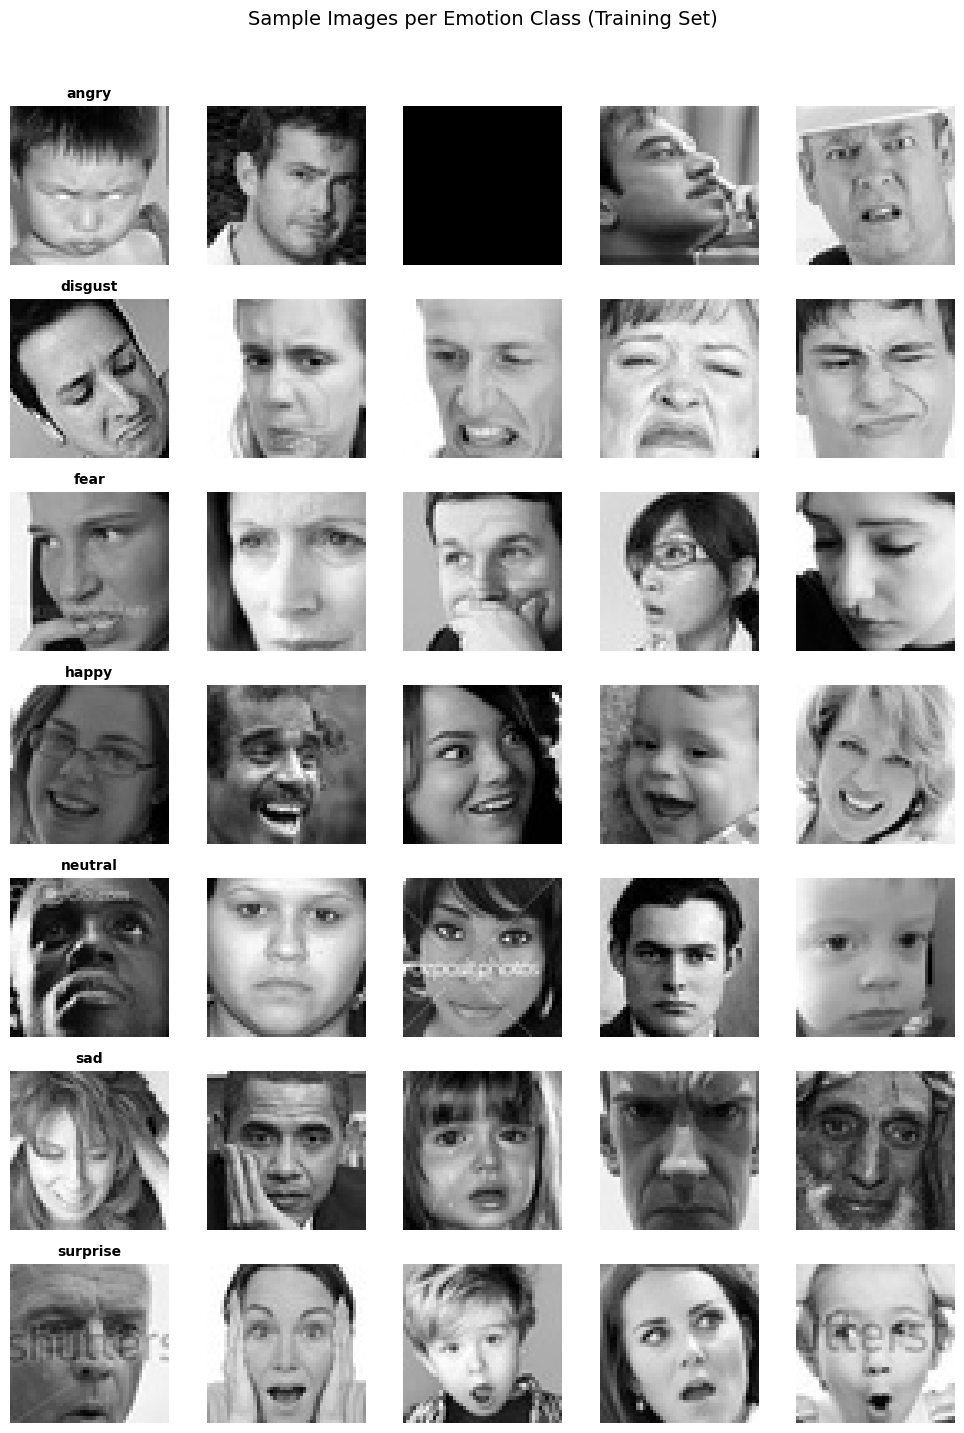

In [ ]:
# Show sample images
def show_sample_grid(data_path, class_names, n_per_class=5):
    """Display a grid with one row per emotion class."""
    n_rows = len(class_names)
    fig, axes = plt.subplots(n_rows, n_per_class,
                             figsize=(n_per_class * 2, n_rows * 2))

    for i, cls in enumerate(class_names):
        cls_dir = data_path / cls
        imgs = sorted([f for f in cls_dir.iterdir()
                       if f.suffix.lower() in IMAGE_EXTS])[:n_per_class]
        for j in range(n_per_class):
            ax = axes[i][j]
            if j < len(imgs):
                img = Image.open(imgs[j])
                ax.imshow(img, cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(cls, fontsize=10, fontweight='bold')

    plt.suptitle('Sample Images per Emotion Class (Training Set)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sample_images_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_grid(splits_info['train']['path'], CLASS_NAMES)

### Image Properties

All images are confirmed 48×48 px and grayscale (1 channel).
The baseline pipeline keeps this native resolution.


In [ ]:
# Check image sizes
sample_cls = CLASS_NAMES[0]
sample_dir = splits_info['train']['path'] / sample_cls
sample_files = sorted([f for f in sample_dir.iterdir()
                       if f.suffix.lower() in IMAGE_EXTS])[:10]

sizes = set()
modes = set()
for fp in sample_files:
    img = Image.open(fp)
    sizes.add(img.size)
    modes.add(img.mode)

print("Image property check (first 10 samples):")
print(f"  Unique sizes : {sizes}")
print(f"  Color modes  : {modes}")

if len(sizes) == 1:
    w, h = list(sizes)[0]
    print(f"  → All sampled images are {w}×{h}")
if 'L' in modes:
    print("  → Images are grayscale (1 channel)")
elif 'RGB' in modes:
    print("  → Images are RGB (3 channels)")

Image property check (first 10 samples):
  Unique sizes : {(48, 48)}
  Color modes  : {'L'}
  → All sampled images are 48×48
  → Images are grayscale (1 channel)


## 4. Preprocessing and Augmentation

We set up two separate pipelines:
- **Baseline CNN** — grayscale 48×48, basic flips/crops during training
- **Transfer Learning** — RGB 224×224, ImageNet mean/std normalization


### Baseline CNN Transforms

Grayscale 48×48 with random horizontal flip and small crop for augmentation.
Test/val uses center crop only — no augmentation.


In [ ]:
# Baseline transforms
IMG_SIZE = 48  # FER-2013 native resolution

baseline_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

baseline_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

print("Baseline transforms defined (grayscale 48×48).")

Baseline transforms defined (grayscale 48×48).


### Transfer Learning Transforms (ResNet-18)

Resize to 224×224, convert to RGB (3-channel), normalize with ImageNet
mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225].


In [ ]:
# TL transforms
TL_IMG_SIZE    = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

tl_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # grayscale → 3-channel
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

tl_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((TL_IMG_SIZE, TL_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transfer learning transforms defined (RGB 224×224, ImageNet normalization).")

Transfer learning transforms defined (RGB 224×224, ImageNet normalization).


## 5. Dataset and DataLoader Setup

We use `ImageFolder` for both pipelines. Since there's no val split,
80 % of train → train (22 967), 20 % → val (5 742). Test stays at 7 178.


In [ ]:
# get labels helper
def get_targets(dataset):
    """Return a list of integer labels for a Dataset or Subset."""
    if isinstance(dataset, Subset):
        return [dataset.dataset.targets[i] for i in dataset.indices]
    elif hasattr(dataset, 'targets'):
        return dataset.targets
    else:
        # Slow fallback
        return [y for _, y in dataset]


def create_datasets_and_loaders(train_transform, test_transform,
                                batch_size=64, val_split=0.2, num_workers=2):
    """Build train / val / test datasets and DataLoaders.

    If a validation folder exists on disk it is used directly.
    Otherwise 'val_split' fraction is held out from the training set.
    """
    train_path = splits_info['train']['path']
    test_path  = splits_info['test']['path']

    test_ds = datasets.ImageFolder(test_path, transform=test_transform)

    if HAS_VAL:
        val_path = splits_info['val']['path']
        train_ds = datasets.ImageFolder(train_path, transform=train_transform)
        val_ds   = datasets.ImageFolder(val_path,   transform=test_transform)
    else:
        # Two ImageFolder objects: one with augmentation, one without
        full_train_aug   = datasets.ImageFolder(train_path, transform=train_transform)
        full_train_clean = datasets.ImageFolder(train_path, transform=test_transform)

        n = len(full_train_aug)
        indices = list(range(n))
        set_seed(42)
        random.shuffle(indices)

        split_idx = int(n * (1 - val_split))
        train_indices = indices[:split_idx]
        val_indices   = indices[split_idx:]

        train_ds = Subset(full_train_aug,   train_indices)
        val_ds   = Subset(full_train_clean, val_indices)

    pin = (device.type == 'cuda')
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin)

    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader

In [ ]:
# baseline loaders
(baseline_train_ds, baseline_val_ds, baseline_test_ds,
 baseline_train_loader, baseline_val_loader, baseline_test_loader) = \
    create_datasets_and_loaders(
        baseline_train_transform,
        baseline_test_transform,
        batch_size=BASELINE_BS,
        num_workers=NUM_WORKERS
    )

print(f"Train samples : {len(baseline_train_ds)}")
print(f"Val samples   : {len(baseline_val_ds)}")
print(f"Test samples  : {len(baseline_test_ds)}")

images, labels = next(iter(baseline_train_loader))
print(f"\nSample batch  : images {images.shape}, labels {labels.shape}")

if hasattr(baseline_test_ds, 'class_to_idx'):
    print(f"Class→Idx     : {baseline_test_ds.class_to_idx}")
else:
    print(f"Class→Idx     : {baseline_test_ds.dataset.class_to_idx}")

Train samples : 22967
Val samples   : 5742
Test samples  : 7178

Sample batch  : images torch.Size([128, 1, 48, 48]), labels torch.Size([128])
Class→Idx     : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


## 6. Baseline CNN

Three convolutional blocks (Conv → BN → ReLU → Pool), followed by a fully-connected head.
Total: **~2.8 M trainable parameters**. Trained entirely from scratch on grayscale images.


In [ ]:
class BaselineCNN(nn.Module):
    """Simple CNN for grayscale 48×48 emotion classification (7 classes)."""

    def __init__(self, num_classes=7):
        super().__init__()

        # Block 1:  1 → 32 channels, 48→24
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Block 2: 32 → 64 channels, 24→12
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Block 3: 64 → 128 channels, 12→6
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

In [ ]:
# build model
def count_parameters(model):
    """Return (trainable, total) parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total

_tmp = BaselineCNN(num_classes=NUM_CLASSES).to(device)
t, a = count_parameters(_tmp)
print(_tmp)
print(f"\nTrainable parameters : {t:,}")
print(f"Total parameters     : {a:,}")
del _tmp

BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2

## 7. Training Utilities

Shared helpers used by all three models:
- `train_one_epoch` / `validate_one_epoch`
- `EarlyStopping` — monitors val loss, stops when stuck
- `train_model` — full loop with scheduler and curve plotting


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate_one_epoch(model, loader, criterion, device):
    """Validate for one epoch. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
class EarlyStopping:
    """Stop training when validation loss stops improving."""

    def __init__(self, patience=5, min_delta=0.001):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = None
        self.should_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                print(f"  ↳ Early stopping triggered (patience={self.patience})")
        else:
            self.best_loss = val_loss
            self.counter = 0

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=30, checkpoint_path=None,
                patience=5, model_name='model'):
    """Full training loop with validation, early stopping, and best-model saving.

    Returns a history dict with per-epoch train/val loss and accuracy.
    """
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    early_stop = EarlyStopping(patience=patience)
    best_val_acc = 0.0
    best_state = None

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = validate_one_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Step the scheduler
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

        lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:>2d}/{epochs}  |  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  |  "
              f"LR: {lr:.6f}")

        early_stop(val_loss)
        if early_stop.should_stop:
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"\n  Best validation accuracy: {best_val_acc:.4f}")
    return history


def plot_training_curves(history, title='Training Curves', save_path=None):
    """Plot loss and accuracy curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Validation')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'b-o', markersize=3, label='Train')
    ax2.plot(epochs, history['val_acc'],   'r-o', markersize=3, label='Validation')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## 8. Evaluation Utilities

Computes accuracy, weighted/macro F1, precision, recall, and saves a confusion matrix.
Metrics are also JSON-dumped to `outputs/metrics/` for comparison later.


In [ ]:
def evaluate_model(model, loader, device, class_names, model_name='Model'):
    """Evaluate model and return metrics dict plus raw predictions."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc         = accuracy_score(all_labels, all_preds)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    macro_f1    = f1_score(all_labels, all_preds, average='macro')
    prec        = precision_score(all_labels, all_preds, average='weighted')
    rec         = recall_score(all_labels, all_preds, average='weighted')

    metrics = {
        'model':       model_name,
        'accuracy':    round(acc, 4),
        'weighted_f1': round(weighted_f1, 4),
        'macro_f1':    round(macro_f1, 4),
        'precision':   round(prec, 4),
        'recall':      round(rec, 4),
    }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Summary")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  Weighted F1   : {weighted_f1:.4f}")
    print(f"  Macro F1      : {macro_f1:.4f}")
    print(f"  Precision (w) : {prec:.4f}")
    print(f"  Recall (w)    : {rec:.4f}")
    print(f"{'='*55}")
    print("\nPer-class classification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return metrics, all_preds, all_labels


def plot_confusion_matrix(y_true, y_pred, class_names,
                          title='Confusion Matrix', save_path=None):
    """Plot and optionally save a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax)

    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(ticks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=9)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def save_metrics(metrics, filepath):
    """Save a metrics dict as JSON."""
    with open(filepath, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"  Metrics saved → {filepath}")

## 9. Baseline CNN — Training

We train the baseline CNN for 30 epochs with Adam (lr=1e-3) and class-weighted loss.
ReduceLROnPlateau scheduler kicks in when val loss plateaus.

**Results on test set:**
- Accuracy: **57.7 %**
- Weighted F1: **55.7 %**
- Best val accuracy (epoch 26): **57.8 %**

Happy (82 % recall) and Surprise (84 % recall) are easiest.
Fear is hardest — only 13 % recall, often confused with Sad/Angry.


In [ ]:
# hyperparams
BASELINE_EPOCHS = 30
BASELINE_LR     = 1e-3
PATIENCE        = 5

# Compute class weights from training set to handle imbalance
train_targets = get_targets(baseline_train_ds)
class_counts  = Counter(train_targets)
total_samples = sum(class_counts.values())

class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)

print("Class weights (inverse frequency):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:>10s}: {class_weights[i]:.3f}")

Class weights (inverse frequency):
       angry: 1.022
     disgust: 9.348
        fear: 0.989
       happy: 0.570
     neutral: 0.820
         sad: 0.869
    surprise: 1.284


In [ ]:
# init model/opt
set_seed(42)

baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
baseline_criterion = nn.CrossEntropyLoss(weight=class_weights)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=BASELINE_LR)

baseline_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print(f"Baseline CNN ready — {count_parameters(baseline_model)[0]:,} trainable params")
print(f"Optimizer: Adam (lr={BASELINE_LR})")
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print("Criterion: CrossEntropyLoss (class-weighted)")

Baseline CNN ready — 2,781,799 trainable params
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
Criterion: CrossEntropyLoss (class-weighted)


In [ ]:
# run training
baseline_history = train_model(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    baseline_criterion,
    baseline_optimizer,
    scheduler=baseline_scheduler,
    epochs=BASELINE_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / 'baseline_cnn_best.pth',
    patience=PATIENCE,
    model_name='Baseline CNN',
)


  Training: Baseline CNN
  Epoch  1/30  |  Train Loss: 2.0022  Acc: 0.1521  |  Val Loss: 1.8998  Acc: 0.1935  |  LR: 0.001000
  Epoch  2/30  |  Train Loss: 1.9130  Acc: 0.1916  |  Val Loss: 1.8070  Acc: 0.2431  |  LR: 0.001000
  Epoch  3/30  |  Train Loss: 1.8366  Acc: 0.2394  |  Val Loss: 1.7346  Acc: 0.2827  |  LR: 0.001000
  Epoch  4/30  |  Train Loss: 1.7605  Acc: 0.2926  |  Val Loss: 1.6535  Acc: 0.3292  |  LR: 0.001000
  Epoch  5/30  |  Train Loss: 1.6771  Acc: 0.3423  |  Val Loss: 1.5173  Acc: 0.4215  |  LR: 0.001000
  Epoch  6/30  |  Train Loss: 1.6016  Acc: 0.3793  |  Val Loss: 1.4502  Acc: 0.4194  |  LR: 0.001000
  Epoch  7/30  |  Train Loss: 1.5394  Acc: 0.4044  |  Val Loss: 1.4490  Acc: 0.4296  |  LR: 0.001000
  Epoch  8/30  |  Train Loss: 1.5054  Acc: 0.4179  |  Val Loss: 1.3846  Acc: 0.4545  |  LR: 0.001000
  Epoch  9/30  |  Train Loss: 1.4735  Acc: 0.4337  |  Val Loss: 1.3496  Acc: 0.4793  |  LR: 0.001000
  Epoch 10/30  |  Train Loss: 1.4402  Acc: 0.4467  |  Val Loss: 1

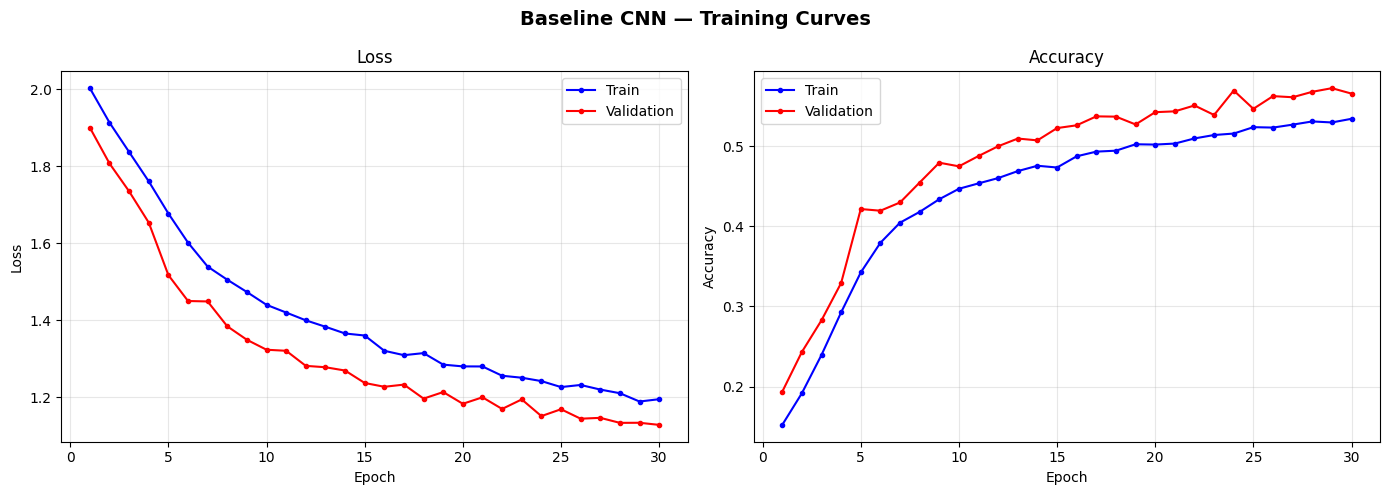

In [ ]:
# plot curves
plot_training_curves(
    baseline_history,
    title='Baseline CNN — Training Curves',
    save_path=FIGURES_DIR / 'baseline_cnn_curves.png',
)


  Baseline CNN — Evaluation Summary
  Accuracy      : 0.5754
  Weighted F1   : 0.5603
  Macro F1      : 0.5082
  Precision (w) : 0.5745
  Recall (w)    : 0.5754

Per-class classification report:
              precision    recall  f1-score   support

       angry       0.55      0.38      0.45       958
     disgust       0.20      0.77      0.32       111
        fear       0.40      0.17      0.24      1024
       happy       0.80      0.83      0.82      1774
     neutral       0.51      0.63      0.56      1233
         sad       0.48      0.44      0.46      1247
    surprise       0.61      0.85      0.71       831

    accuracy                           0.58      7178
   macro avg       0.51      0.58      0.51      7178
weighted avg       0.57      0.58      0.56      7178



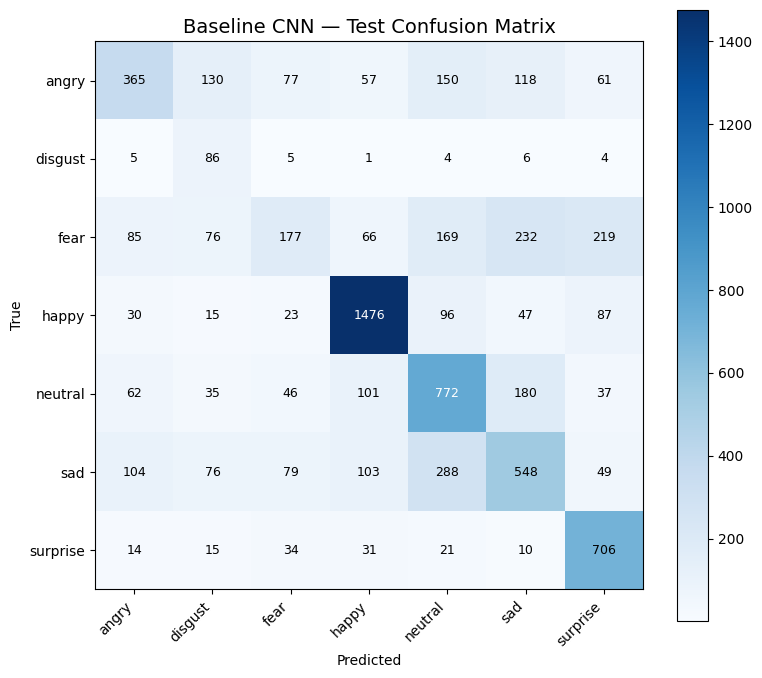

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/baseline_cnn_metrics.json


In [ ]:
# test evaluation
baseline_metrics, baseline_preds, baseline_labels = evaluate_model(
    baseline_model, baseline_test_loader, device, CLASS_NAMES,
    model_name='Baseline CNN',
)

# Add best val accuracy from training
baseline_metrics['val_acc'] = round(max(baseline_history['val_acc']), 4)

# Confusion matrix
plot_confusion_matrix(
    baseline_labels, baseline_preds, CLASS_NAMES,
    title='Baseline CNN — Test Confusion Matrix',
    save_path=FIGURES_DIR / 'baseline_cnn_confusion.png',
)

# Save metrics
save_metrics(baseline_metrics, METRICS_DIR / 'baseline_cnn_metrics.json')

# Start result collection for comparison
all_results = [baseline_metrics]

## 10. Transfer Learning with ResNet-18

We adapt a pretrained ResNet-18 (ImageNet) to FER-2013 in two stages:
1. **Feature Extraction** — freeze all ResNet layers, train only the new head (20 epochs)
2. **Fine-Tuning** — unfreeze layer3 + layer4, use smaller LR (20 epochs)

Images are resized to 224×224 RGB and normalized with ImageNet stats.


In [ ]:
def create_resnet18(num_classes=7, freeze_backbone=True):
    """Create a ResNet-18 with a replaced FC head for emotion classification.

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    freeze_backbone : bool
        If True, freeze all backbone parameters (feature extraction mode).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes),
    )

    return model

In [ ]:
# TL data loaders
(tl_train_ds, tl_val_ds, tl_test_ds,
 tl_train_loader, tl_val_loader, tl_test_loader) = \
    create_datasets_and_loaders(
        tl_train_transform,
        tl_test_transform,
        batch_size=TL_BS,
        num_workers=NUM_WORKERS
    )

print(f"TL Train samples : {len(tl_train_ds)}")
print(f"TL Val samples   : {len(tl_val_ds)}")
print(f"TL Test samples  : {len(tl_test_ds)}")

imgs, lbls = next(iter(tl_train_loader))
print(f"Sample TL batch  : images {imgs.shape}, labels {lbls.shape}")

TL Train samples : 22967
TL Val samples   : 5742
TL Test samples  : 7178
Sample TL batch  : images torch.Size([64, 3, 224, 224]), labels torch.Size([64])


### Feature Extraction (Frozen Backbone)

Only the classification head (3 591 params) is trained; ResNet weights stay frozen.
ImageNet features transfer poorly to low-res grayscale-turned-RGB faces.

**Test results:**
- Accuracy: **39.2 %** — surprisingly below the baseline
- Weighted F1: **37.8 %**

Happy and Surprise still pop out, but Disgust (12 % F1) and Fear (22 % F1) struggle.
The frozen backbone hasn't learned face-specific features, so performance is limited.


In [ ]:
# FE setup
FE_EPOCHS = 20
FE_LR = 1e-3

set_seed(42)
fe_model = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)

trainable, total = count_parameters(fe_model)
print("ResNet-18 Feature Extraction")
print(f"  Trainable params : {trainable:,} / {total:,}")

fe_criterion = nn.CrossEntropyLoss(weight=class_weights)
fe_optimizer = optim.Adam(fe_model.fc.parameters(), lr=FE_LR)

fe_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fe_optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

fe_history = train_model(
    fe_model, tl_train_loader, tl_val_loader,
    fe_criterion, fe_optimizer, fe_scheduler,
    epochs=FE_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / 'resnet18_feature_extract_best.pth',
    patience=PATIENCE,
    model_name='ResNet-18 (Feature Extraction)',
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


ResNet-18 Feature Extraction
  Trainable params : 3,591 / 11,180,103

  Training: ResNet-18 (Feature Extraction)
  Epoch  1/20  |  Train Loss: 1.9487  Acc: 0.2274  |  Val Loss: 1.7203  Acc: 0.3692  |  LR: 0.001000
  Epoch  2/20  |  Train Loss: 1.8291  Acc: 0.2762  |  Val Loss: 1.6846  Acc: 0.3546  |  LR: 0.001000
  Epoch  3/20  |  Train Loss: 1.8099  Acc: 0.2890  |  Val Loss: 1.7004  Acc: 0.3863  |  LR: 0.001000
  Epoch  4/20  |  Train Loss: 1.7957  Acc: 0.2916  |  Val Loss: 1.6784  Acc: 0.3556  |  LR: 0.001000
  Epoch  5/20  |  Train Loss: 1.8013  Acc: 0.2864  |  Val Loss: 1.6997  Acc: 0.3830  |  LR: 0.001000
  Epoch  6/20  |  Train Loss: 1.8130  Acc: 0.2874  |  Val Loss: 1.6884  Acc: 0.3826  |  LR: 0.001000
  Epoch  7/20  |  Train Loss: 1.7927  Acc: 0.2968  |  Val Loss: 1.6756  Acc: 0.3957  |  LR: 0.001000
  Epoch  8/20  |  Train Loss: 1.8020  Acc: 0.2914  |  Val Loss: 1.6909  Acc: 0.3880  |  LR: 0.001000
  Epoch  9/20  |  Train Loss: 1.8089  Acc: 0.2883  |  Val Loss: 1.7158  Acc: 0.

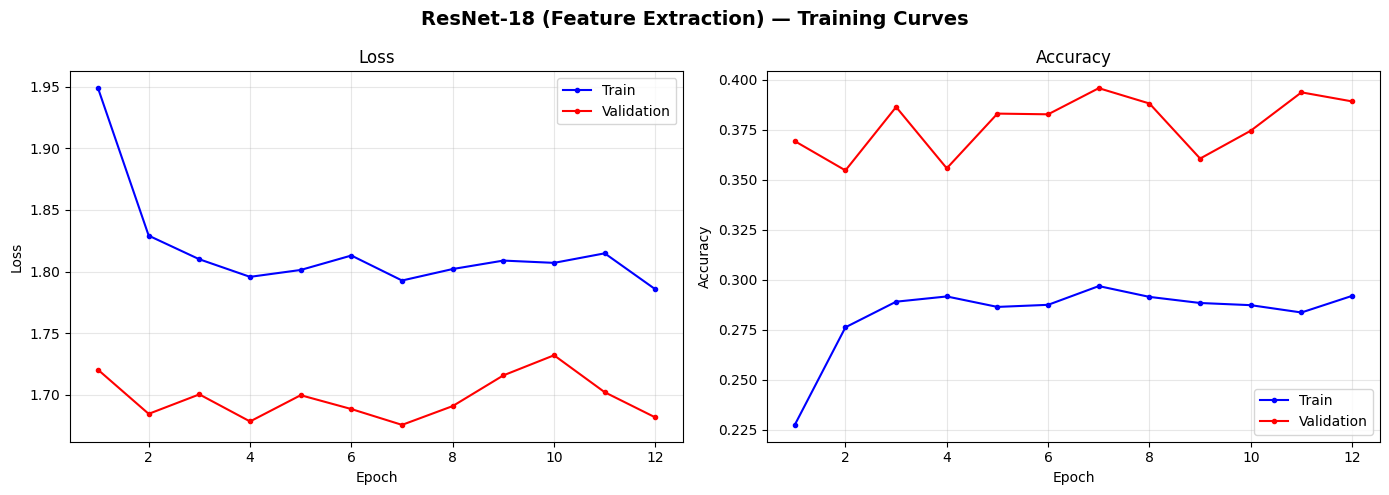


  ResNet-18 (Feature Extraction) — Evaluation Summary
  Accuracy      : 0.3930
  Weighted F1   : 0.3783
  Macro F1      : 0.3362
  Precision (w) : 0.3871
  Recall (w)    : 0.3930

Per-class classification report:
              precision    recall  f1-score   support

       angry       0.28      0.30      0.29       958
     disgust       0.09      0.19      0.12       111
        fear       0.25      0.20      0.22      1024
       happy       0.49      0.60      0.54      1774
     neutral       0.39      0.37      0.38      1233
         sad       0.41      0.19      0.26      1247
    surprise       0.47      0.67      0.55       831

    accuracy                           0.39      7178
   macro avg       0.34      0.36      0.34      7178
weighted avg       0.39      0.39      0.38      7178



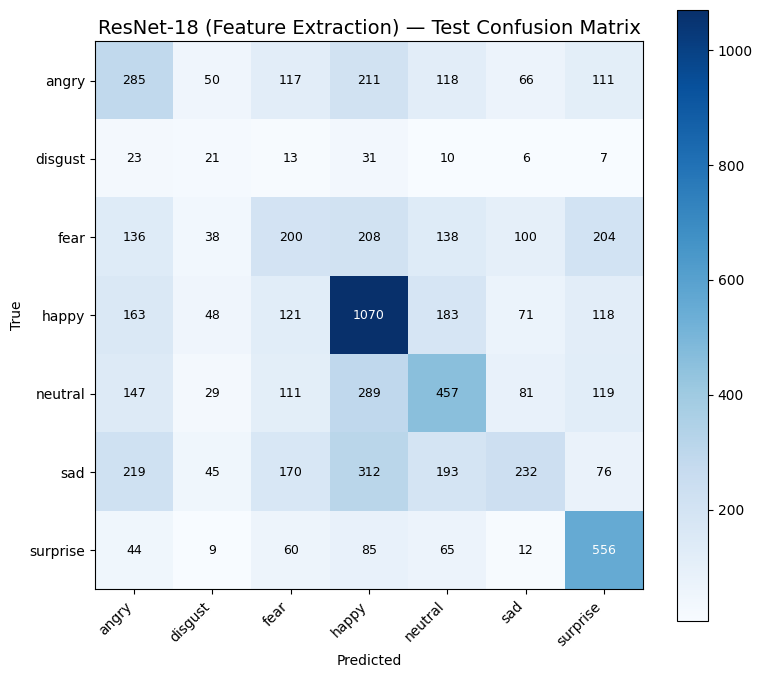

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/resnet18_fe_metrics.json


In [ ]:
# evaluate FE
plot_training_curves(
    fe_history,
    title='ResNet-18 (Feature Extraction) — Training Curves',
    save_path=FIGURES_DIR / 'resnet18_fe_curves.png',
)

fe_metrics, fe_preds, fe_labels = evaluate_model(
    fe_model, tl_test_loader, device, CLASS_NAMES,
    model_name='ResNet-18 (Feature Extraction)',
)
fe_metrics['val_acc'] = round(max(fe_history['val_acc']), 4)

plot_confusion_matrix(
    fe_labels, fe_preds, CLASS_NAMES,
    title='ResNet-18 (Feature Extraction) — Test Confusion Matrix',
    save_path=FIGURES_DIR / 'resnet18_fe_confusion.png',
)

save_metrics(fe_metrics, METRICS_DIR / 'resnet18_fe_metrics.json')
all_results.append(fe_metrics)

### Fine-Tuning (Partial Unfreeze)

Unfreeze layer3, layer4, and the head. Use a small backbone LR (1e-4) vs
a larger head LR (1e-3). This lets the model adapt ImageNet features to faces.

**Test results:**
- Accuracy: **66.6 %** — clear best across all three models
- Weighted F1: **66.5 %**

Disgust jumps to 69 % F1 (vs 35 % baseline). Happy hits 87 % F1.
Fear is still the weakest at 50 % F1, but much better than before.


In [ ]:
# FT setup
FT_EPOCHS       = 20
FT_LR_BACKBONE  = 1e-4
FT_LR_HEAD      = 1e-3

set_seed(42)
ft_model = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)

# Freeze everything except layer3, layer4, fc
for name, param in ft_model.named_parameters():
    if not any(part in name for part in ['layer3', 'layer4', 'fc']):
        param.requires_grad = False

trainable, total = count_parameters(ft_model)
print(f"ResNet-18 Fine-Tuning")
print(f"  Trainable params : {trainable:,} / {total:,}")

# Differential learning rates
ft_optimizer = optim.Adam([
    {'params': ft_model.layer3.parameters(), 'lr': FT_LR_BACKBONE},
    {'params': ft_model.layer4.parameters(), 'lr': FT_LR_BACKBONE},
    {'params': ft_model.fc.parameters(),     'lr': FT_LR_HEAD},
])
ft_criterion = nn.CrossEntropyLoss(weight=class_weights)
ft_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    ft_optimizer, mode='min', factor=0.5, patience=3
)

ft_history = train_model(
    ft_model, tl_train_loader, tl_val_loader,
    ft_criterion, ft_optimizer, ft_scheduler,
    epochs=FT_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / 'resnet18_finetune_best.pth',
    patience=PATIENCE,
    model_name='ResNet-18 (Fine-Tuning)',
)

ResNet-18 Fine-Tuning
  Trainable params : 10,497,031 / 11,180,103

  Training: ResNet-18 (Fine-Tuning)
  Epoch  1/20  |  Train Loss: 1.5043  Acc: 0.4388  |  Val Loss: 1.2530  Acc: 0.4977  |  LR: 0.000100
  Epoch  2/20  |  Train Loss: 1.1687  Acc: 0.5567  |  Val Loss: 1.1074  Acc: 0.5813  |  LR: 0.000100
  Epoch  3/20  |  Train Loss: 1.0401  Acc: 0.5991  |  Val Loss: 1.0729  Acc: 0.6069  |  LR: 0.000100
  Epoch  4/20  |  Train Loss: 0.9423  Acc: 0.6330  |  Val Loss: 1.1078  Acc: 0.5942  |  LR: 0.000100
  Epoch  5/20  |  Train Loss: 0.8653  Acc: 0.6610  |  Val Loss: 1.1200  Acc: 0.6390  |  LR: 0.000100
  Epoch  6/20  |  Train Loss: 0.8074  Acc: 0.6801  |  Val Loss: 1.0912  Acc: 0.6040  |  LR: 0.000100
  Epoch  7/20  |  Train Loss: 0.7396  Acc: 0.7040  |  Val Loss: 1.1111  Acc: 0.6325  |  LR: 0.000050
  Epoch  8/20  |  Train Loss: 0.6123  Acc: 0.7543  |  Val Loss: 1.1774  Acc: 0.6526  |  LR: 0.000050
  ↳ Early stopping triggered (patience=5)

  Best validation accuracy: 0.6526


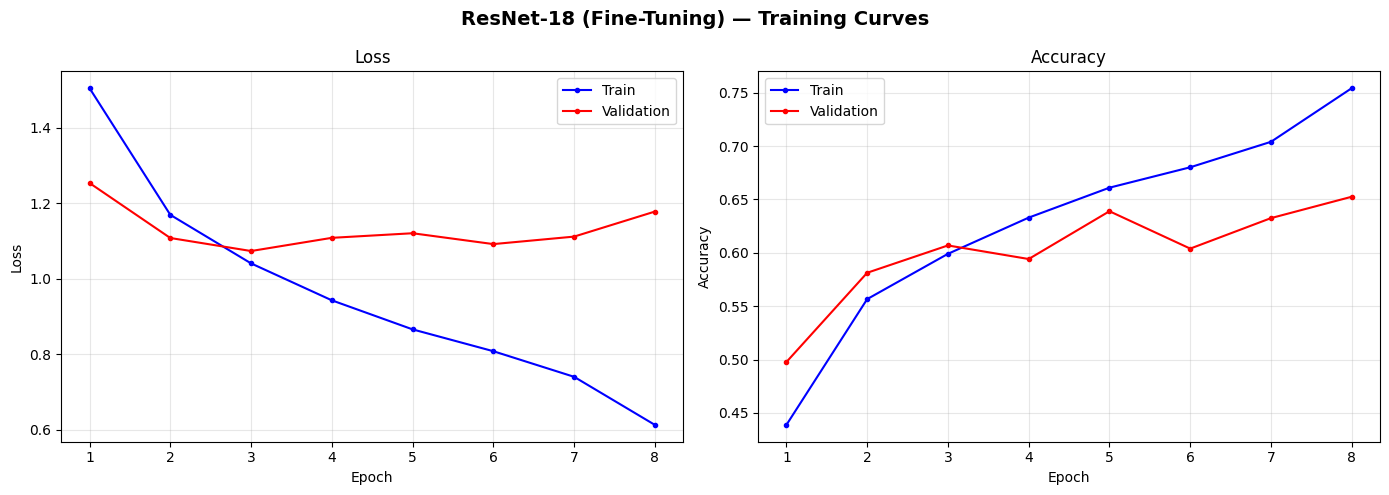


  ResNet-18 (Fine-Tuning) — Evaluation Summary
  Accuracy      : 0.6610
  Weighted F1   : 0.6544
  Macro F1      : 0.6359
  Precision (w) : 0.6611
  Recall (w)    : 0.6610

Per-class classification report:
              precision    recall  f1-score   support

       angry       0.61      0.57      0.59       958
     disgust       0.54      0.71      0.62       111
        fear       0.60      0.38      0.46      1024
       happy       0.83      0.89      0.86      1774
     neutral       0.65      0.55      0.60      1233
         sad       0.50      0.63      0.55      1247
    surprise       0.71      0.85      0.77       831

    accuracy                           0.66      7178
   macro avg       0.63      0.65      0.64      7178
weighted avg       0.66      0.66      0.65      7178



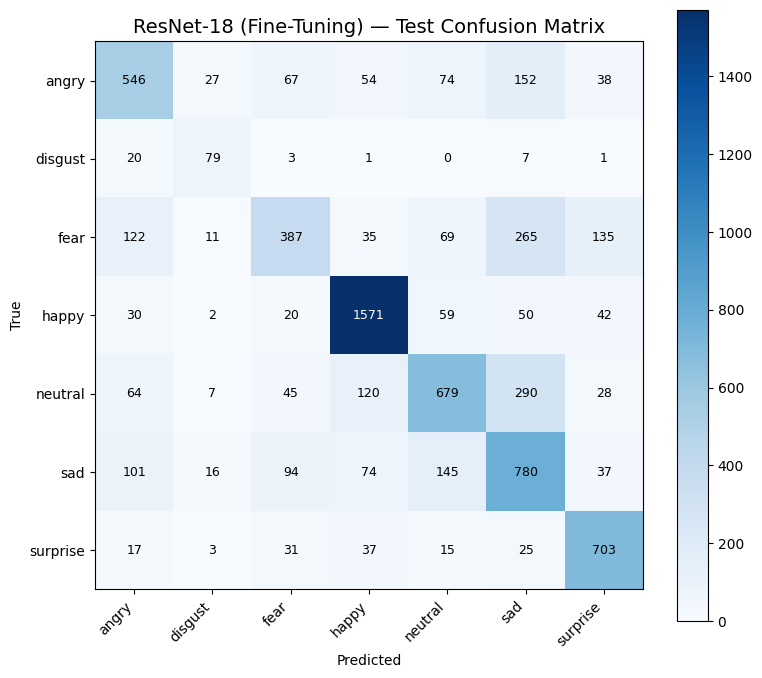

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/resnet18_ft_metrics.json


In [ ]:
# evaluate FT
plot_training_curves(
    ft_history,
    title='ResNet-18 (Fine-Tuning) — Training Curves',
    save_path=FIGURES_DIR / 'resnet18_ft_curves.png',
)

ft_metrics, ft_preds, ft_labels = evaluate_model(
    ft_model, tl_test_loader, device, CLASS_NAMES,
    model_name='ResNet-18 (Fine-Tuning)',
)
ft_metrics['val_acc'] = round(max(ft_history['val_acc']), 4)

plot_confusion_matrix(
    ft_labels, ft_preds, CLASS_NAMES,
    title='ResNet-18 (Fine-Tuning) — Test Confusion Matrix',
    save_path=FIGURES_DIR / 'resnet18_ft_confusion.png',
)

save_metrics(ft_metrics, METRICS_DIR / 'resnet18_ft_metrics.json')
all_results.append(ft_metrics)

## 11. Baseline CNN and ResNet-18 Results

The baseline CNN and ResNet-18 sections above are kept as comparison runs. In the current results, the custom baseline CNN is around 57% test accuracy, while ResNet-18 fine-tuning is around 66% and remains the strongest previous model.

The final comparison table is generated from the metrics produced by notebook evaluation cells, not from hardcoded target values.


## EfficientNet-B0 Attempt: Transfer Learning

EfficientNet-B0 was added as a lightweight transfer-learning attempt because it is practical for later webcam inference. However, the current run is around 56% test accuracy and does not outperform the ResNet-18 fine-tuning result. It is kept in the notebook as an attempted model and comparison point, but it should not be treated as the final improved model unless a future run actually improves its real evaluation metrics.

The next section adds ConvNeXt-Tiny as the stronger final model attempt.


### EfficientNet Configuration and Data Pipeline

FER-2013 images are grayscale 48x48, while ImageNet-pretrained EfficientNet expects 3-channel normalized images. These transforms convert grayscale images to RGB, resize to the selected EfficientNet input size, apply safe face-preserving augmentation, and use ImageNet normalization.


In [ ]:
# EfficientNet configuration
EFFICIENTNET_VARIANT = 'efficientnet_b0'  # options: 'efficientnet_b0', 'efficientnet_b2'

EFFICIENTNET_CONFIGS = {
    'efficientnet_b0': {
        'display_name': 'EfficientNet-B0',
        'builder': models.efficientnet_b0,
        'weights': models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        'image_size': 224,
        'batch_size': 64,
        'head_dropout': 0.40,
    },
    'efficientnet_b2': {
        'display_name': 'EfficientNet-B2',
        'builder': models.efficientnet_b2,
        'weights': models.EfficientNet_B2_Weights.IMAGENET1K_V1,
        'image_size': 260,
        'batch_size': 32,
        'head_dropout': 0.45,
    },
}

if EFFICIENTNET_VARIANT not in EFFICIENTNET_CONFIGS:
    raise ValueError(f"Unknown EfficientNet variant: {EFFICIENTNET_VARIANT}")

EFF_CFG = EFFICIENTNET_CONFIGS[EFFICIENTNET_VARIANT]
EFF_DISPLAY_NAME = EFF_CFG['display_name']
EFF_IMG_SIZE = EFF_CFG['image_size']
EFF_BATCH_SIZE = EFF_CFG['batch_size']

print(f"Selected model : {EFF_DISPLAY_NAME}")
print(f"Input size     : {EFF_IMG_SIZE}x{EFF_IMG_SIZE}")
print(f"Batch size     : {EFF_BATCH_SIZE}")


def build_efficientnet_transforms(image_size):
    """Create train/test transforms for ImageNet-pretrained EfficientNet."""
    train_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.20, contrast=0.20),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.5, 2.0), value='random'),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    test_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    return train_transform, test_transform


eff_train_transform, eff_test_transform = build_efficientnet_transforms(EFF_IMG_SIZE)

(eff_train_ds, eff_val_ds, eff_test_ds,
 eff_train_loader, eff_val_loader, eff_test_loader) =     create_datasets_and_loaders(
        eff_train_transform,
        eff_test_transform,
        batch_size=EFF_BATCH_SIZE,
        num_workers=NUM_WORKERS,
    )

# Recompute class weights from the EfficientNet training split.
eff_train_targets = get_targets(eff_train_ds)
eff_class_counts = Counter(eff_train_targets)
eff_total_samples = sum(eff_class_counts.values())
eff_class_weights = torch.tensor(
    [eff_total_samples / (NUM_CLASSES * eff_class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(device)

print(f"EfficientNet Train samples : {len(eff_train_ds)}")
print(f"EfficientNet Val samples   : {len(eff_val_ds)}")
print(f"EfficientNet Test samples  : {len(eff_test_ds)}")
print("EfficientNet class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:>10s}: {eff_class_weights[i]:.3f}")

imgs, lbls = next(iter(eff_train_loader))
print(f"Sample EfficientNet batch  : images {imgs.shape}, labels {lbls.shape}")


Selected model : EfficientNet-B0
Input size     : 224x224
Batch size     : 64
EfficientNet Train samples : 22967
EfficientNet Val samples   : 5742
EfficientNet Test samples  : 7178
EfficientNet class weights:
       angry: 1.022
     disgust: 9.348
        fear: 0.989
       happy: 0.570
     neutral: 0.820
         sad: 0.869
    surprise: 1.284
Sample EfficientNet batch  : images torch.Size([64, 3, 224, 224]), labels torch.Size([64])


### Model Definition and Training Helpers

The EfficientNet classifier is replaced with a dropout + linear head for 7 emotion classes. Training uses weighted cross-entropy with label smoothing, AdamW, mixed precision on CUDA, ReduceLROnPlateau, and early stopping based on validation weighted F1.


In [ ]:
def create_efficientnet_model(config, num_classes=7, freeze_backbone=True):
    """Create an ImageNet-pretrained EfficientNet with a FER-2013 classifier head."""
    model = config['builder'](weights=config['weights'])

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=config['head_dropout'], inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model


def set_efficientnet_feature_extraction(model):
    """Freeze the EfficientNet backbone and train only the classifier head."""
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True


def set_efficientnet_finetuning(model, unfreeze_from_block=6):
    """Freeze early EfficientNet blocks, unfreeze later blocks and classifier head."""
    for param in model.features.parameters():
        param.requires_grad = False

    for block_idx, block in enumerate(model.features):
        if block_idx >= unfreeze_from_block:
            for param in block.parameters():
                param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True


def make_weighted_label_smoothing_loss(weights, smoothing=0.05):
    """Use class-weighted CE with label smoothing when supported by the PyTorch version."""
    try:
        return nn.CrossEntropyLoss(weight=weights, label_smoothing=smoothing)
    except TypeError:
        print("label_smoothing is not available in this PyTorch version; using weighted CE only.")
        return nn.CrossEntropyLoss(weight=weights)


def copy_model_state_to_cpu(model):
    """Copy a model state_dict to CPU before checkpointing to reduce GPU memory pressure."""
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def run_efficientnet_epoch(model, loader, criterion, optimizer=None, scaler=None, use_amp=False):
    """Run one training or validation epoch and return loss/accuracy/F1 metrics."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    total = 0
    all_preds = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / total
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    return avg_loss, acc, macro_f1, weighted_f1


def train_efficientnet_model(model, train_loader, val_loader, criterion, optimizer,
                             scheduler=None, epochs=20, checkpoint_path=None,
                             patience=5, min_delta=0.001, model_name='EfficientNet',
                             initial_best_metrics=None):
    """Train EfficientNet with early stopping on validation weighted F1."""
    history = {
        'train_loss': [], 'train_acc': [], 'train_macro_f1': [], 'train_weighted_f1': [],
        'val_loss': [], 'val_acc': [], 'val_macro_f1': [], 'val_weighted_f1': [],
    }

    use_amp = (device.type == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_metrics = dict(initial_best_metrics) if initial_best_metrics else {'val_weighted_f1': -np.inf}
    best_score = best_metrics.get('val_weighted_f1', -np.inf)
    best_state = copy_model_state_to_cpu(model)
    epochs_without_improvement = 0

    print(f"\n{'='*72}")
    print(f"  Training: {model_name}")
    print(f"  Mixed precision: {'enabled' if use_amp else 'disabled'}")
    print(f"{'='*72}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1, train_weighted_f1 = run_efficientnet_epoch(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler, use_amp=use_amp
        )
        val_loss, val_acc, val_macro_f1, val_weighted_f1 = run_efficientnet_epoch(
            model, val_loader, criterion, optimizer=None, scaler=None, use_amp=use_amp
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_macro_f1'].append(train_macro_f1)
        history['train_weighted_f1'].append(train_weighted_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_macro_f1)
        history['val_weighted_f1'].append(val_weighted_f1)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_weighted_f1)
            else:
                scheduler.step()

        improved = val_weighted_f1 > best_score + min_delta
        if improved:
            best_score = val_weighted_f1
            best_metrics = {
                'val_loss': val_loss,
                'val_acc': val_acc,
                'val_macro_f1': val_macro_f1,
                'val_weighted_f1': val_weighted_f1,
            }
            best_state = copy_model_state_to_cpu(model)
            epochs_without_improvement = 0

            if checkpoint_path is not None:
                torch.save({
                    'variant': EFFICIENTNET_VARIANT,
                    'display_name': EFF_DISPLAY_NAME,
                    'image_size': EFF_IMG_SIZE,
                    'class_names': CLASS_NAMES,
                    'model_state_dict': best_state,
                    'best_metrics': best_metrics,
                    'history': history,
                }, checkpoint_path)
        else:
            epochs_without_improvement += 1

        lr_summary = ', '.join(f"{group['lr']:.2e}" for group in optimizer.param_groups)
        print(
            f"  Epoch {epoch:>2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f} | "
            f"Val Weighted F1: {val_weighted_f1:.4f} | "
            f"LR: {lr_summary}"
        )

        if epochs_without_improvement >= patience:
            print(f"  Early stopping: validation weighted F1 did not improve for {patience} epochs.")
            break

    model.load_state_dict(best_state)
    print(f"\n  Best validation weighted F1: {best_metrics.get('val_weighted_f1', 0.0):.4f}")
    return history, best_metrics


### Feature Extraction (Frozen Backbone)

Start by freezing the EfficientNet backbone and training only the new classifier head. This adapts the ImageNet representation to FER-2013 without immediately overwriting pretrained features.


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 271MB/s]

EfficientNet-B0 Feature Extraction
  Trainable params : 8,967 / 4,016,515

  Training: EfficientNet-B0 (Feature Extraction)
  Mixed precision: enabled


  Epoch  1/5 | Train Loss: 1.9177 | Val Loss: 1.8357 | Val Acc: 0.3358 | Val Macro F1: 0.3107 | Val Weighted F1: 0.3543 | LR: 1.00e-03
  Epoch  2/5 | Train Loss: 1.8525 | Val Loss: 1.8057 | Val Acc: 0.3896 | Val Macro F1: 0.3441 | Val Weighted F1: 0.3967 | LR: 1.00e-03
  Epoch  3/5 | Train Loss: 1.8449 | Val Loss: 1.7952 | Val Acc: 0.3913 | Val Macro F1: 0.3472 | Val Weighted F1: 0.4007 | LR: 1.00e-03
  Epoch  4/5 | Train Loss: 1.8449 | Val Loss: 1.7862 | Val Acc: 0.3995 | Val Macro F1: 0.3617 | Val Weighted F1: 0.4116 | LR: 1.00e-03
  Epoch  5/5 | Train Loss: 1.8393 | Val Loss: 1.7876 | Val Acc: 0.4056 | Val Macro F1: 0.3643 | Val Weighted F1: 0.4147 | LR: 1.00e-03

  Best validation weighted F1: 0.4147


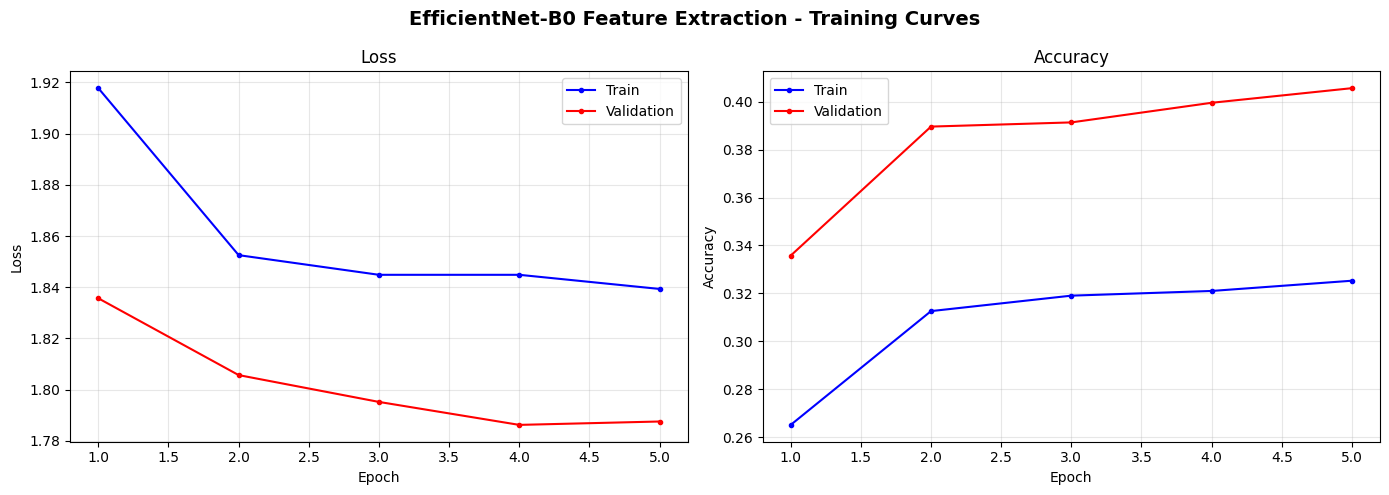

In [ ]:
# EfficientNet feature extraction setup
EFF_FE_EPOCHS = 5
EFF_FE_LR = 1e-3
EFF_WEIGHT_DECAY = 1e-4
EFF_LABEL_SMOOTHING = 0.05
EFF_PATIENCE = 5
EFF_CHECKPOINT_PATH = CHECKPOINT_DIR / f'{EFFICIENTNET_VARIANT}_best_weighted_f1.pth'

set_seed(42)
efficientnet_model = create_efficientnet_model(
    EFF_CFG,
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
).to(device)
set_efficientnet_feature_extraction(efficientnet_model)

trainable, total = count_parameters(efficientnet_model)
print(f"{EFF_DISPLAY_NAME} Feature Extraction")
print(f"  Trainable params : {trainable:,} / {total:,}")

# Class-weighted CE with label smoothing handles imbalance without hardcoding outcomes.
eff_criterion = make_weighted_label_smoothing_loss(
    eff_class_weights,
    smoothing=EFF_LABEL_SMOOTHING,
)
eff_fe_optimizer = optim.AdamW(
    efficientnet_model.classifier.parameters(),
    lr=EFF_FE_LR,
    weight_decay=EFF_WEIGHT_DECAY,
)
eff_fe_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    eff_fe_optimizer,
    mode='max',
    factor=0.5,
    patience=2,
)

eff_fe_history, eff_best_metrics = train_efficientnet_model(
    efficientnet_model,
    eff_train_loader,
    eff_val_loader,
    eff_criterion,
    eff_fe_optimizer,
    scheduler=eff_fe_scheduler,
    epochs=EFF_FE_EPOCHS,
    checkpoint_path=EFF_CHECKPOINT_PATH,
    patience=EFF_PATIENCE,
    model_name=f'{EFF_DISPLAY_NAME} (Feature Extraction)',
)

plot_training_curves(
    eff_fe_history,
    title=f'{EFF_DISPLAY_NAME} Feature Extraction - Training Curves',
    save_path=FIGURES_DIR / f'{EFFICIENTNET_VARIANT}_feature_extract_curves.png',
)


### Fine-Tuning Later EfficientNet Blocks

After the classifier head has adapted, unfreeze only the later EfficientNet blocks and keep early layers frozen. The pretrained layers use a smaller learning rate, while the classifier head uses a slightly higher learning rate.


EfficientNet-B0 Fine-Tuning
  Unfrozen feature blocks from index : 6
  Trainable params                  : 3,164,707 / 4,016,515

  Training: EfficientNet-B0 (Fine-Tuning)
  Mixed precision: enabled
  Epoch  1/20 | Train Loss: 1.8006 | Val Loss: 1.7283 | Val Acc: 0.4281 | Val Macro F1: 0.3795 | Val Weighted F1: 0.4335 | LR: 1.00e-05, 3.00e-04
  Epoch  2/20 | Train Loss: 1.7494 | Val Loss: 1.6905 | Val Acc: 0.4525 | Val Macro F1: 0.4053 | Val Weighted F1: 0.4634 | LR: 1.00e-05, 3.00e-04
  Epoch  3/20 | Train Loss: 1.7121 | Val Loss: 1.6621 | Val Acc: 0.4702 | Val Macro F1: 0.4209 | Val Weighted F1: 0.4796 | LR: 1.00e-05, 3.00e-04
  Epoch  4/20 | Train Loss: 1.6868 | Val Loss: 1.6298 | Val Acc: 0.4680 | Val Macro F1: 0.4224 | Val Weighted F1: 0.4849 | LR: 1.00e-05, 3.00e-04
  Epoch  5/20 | Train Loss: 1.6624 | Val Loss: 1.6203 | Val Acc: 0.4930 | Val Macro F1: 0.4415 | Val Weighted F1: 0.4999 | LR: 1.00e-05, 3.00e-04
  Epoch  6/20 | Train Loss: 1.6368 | Val Loss: 1.5879 | Val Acc: 0.4754

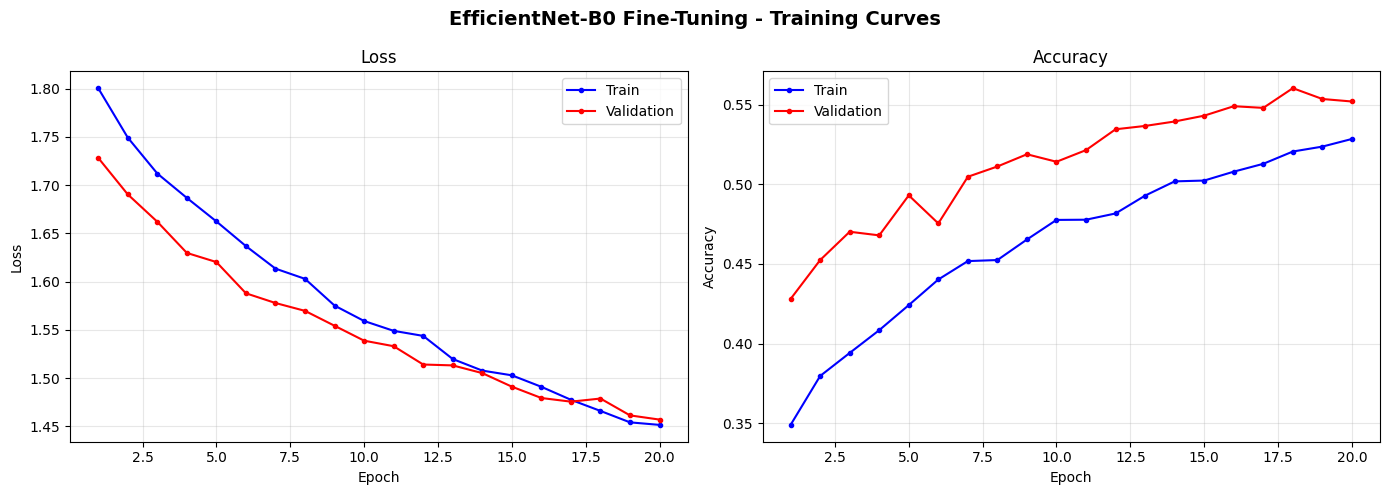

In [ ]:
# EfficientNet fine-tuning setup
EFF_FT_EPOCHS = 20
EFF_LR_BACKBONE = 1e-5
EFF_LR_HEAD = 3e-4
EFFICIENTNET_UNFREEZE_FROM_BLOCK = 6

# Start fine-tuning from the best feature-extraction checkpoint.
eff_checkpoint = torch.load(EFF_CHECKPOINT_PATH, map_location=device)
efficientnet_model.load_state_dict(eff_checkpoint['model_state_dict'])
set_efficientnet_finetuning(
    efficientnet_model,
    unfreeze_from_block=EFFICIENTNET_UNFREEZE_FROM_BLOCK,
)

trainable, total = count_parameters(efficientnet_model)
print(f"{EFF_DISPLAY_NAME} Fine-Tuning")
print(f"  Unfrozen feature blocks from index : {EFFICIENTNET_UNFREEZE_FROM_BLOCK}")
print(f"  Trainable params                  : {trainable:,} / {total:,}")

backbone_params = [
    param for name, param in efficientnet_model.named_parameters()
    if param.requires_grad and name.startswith('features')
]
head_params = [
    param for name, param in efficientnet_model.named_parameters()
    if param.requires_grad and name.startswith('classifier')
]

param_groups = []
if backbone_params:
    param_groups.append({'params': backbone_params, 'lr': EFF_LR_BACKBONE})
if head_params:
    param_groups.append({'params': head_params, 'lr': EFF_LR_HEAD})

eff_ft_optimizer = optim.AdamW(
    param_groups,
    weight_decay=EFF_WEIGHT_DECAY,
)
eff_ft_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    eff_ft_optimizer,
    mode='max',
    factor=0.5,
    patience=3,
)

eff_ft_history, eff_best_metrics = train_efficientnet_model(
    efficientnet_model,
    eff_train_loader,
    eff_val_loader,
    eff_criterion,
    eff_ft_optimizer,
    scheduler=eff_ft_scheduler,
    epochs=EFF_FT_EPOCHS,
    checkpoint_path=EFF_CHECKPOINT_PATH,
    patience=EFF_PATIENCE,
    model_name=f'{EFF_DISPLAY_NAME} (Fine-Tuning)',
    initial_best_metrics=eff_best_metrics,
)

plot_training_curves(
    eff_ft_history,
    title=f'{EFF_DISPLAY_NAME} Fine-Tuning - Training Curves',
    save_path=FIGURES_DIR / f'{EFFICIENTNET_VARIANT}_finetune_curves.png',
)


### EfficientNet Test Evaluation

The best saved EfficientNet checkpoint is loaded before test evaluation. The metrics below are computed from model predictions and should be reported as-is, even if they are below the 80% target.


Loaded best checkpoint: /content/drive/MyDrive/emotion_project/outputs/checkpoints/efficientnet_b0_best_weighted_f1.pth
Best validation weighted F1: 0.5634

  EfficientNet-B0 Attempt - Test Evaluation
  Test Accuracy : 0.5600
  Macro F1      : 0.5026
  Weighted F1   : 0.5600
  Precision (w) : 0.5764
  Recall (w)    : 0.5600

Full classification report:
              precision    recall  f1-score   support

       angry       0.44      0.50      0.47       958
     disgust       0.16      0.65      0.26       111
        fear       0.44      0.22      0.29      1024
       happy       0.82      0.79      0.80      1774
     neutral       0.52      0.57      0.54      1233
         sad       0.45      0.45      0.45      1247
    surprise       0.70      0.70      0.70       831

    accuracy                           0.56      7178
   macro avg       0.51      0.55      0.50      7178
weighted avg       0.58      0.56      0.56      7178

Per-class accuracy/F1:
   class  accuracy     f1

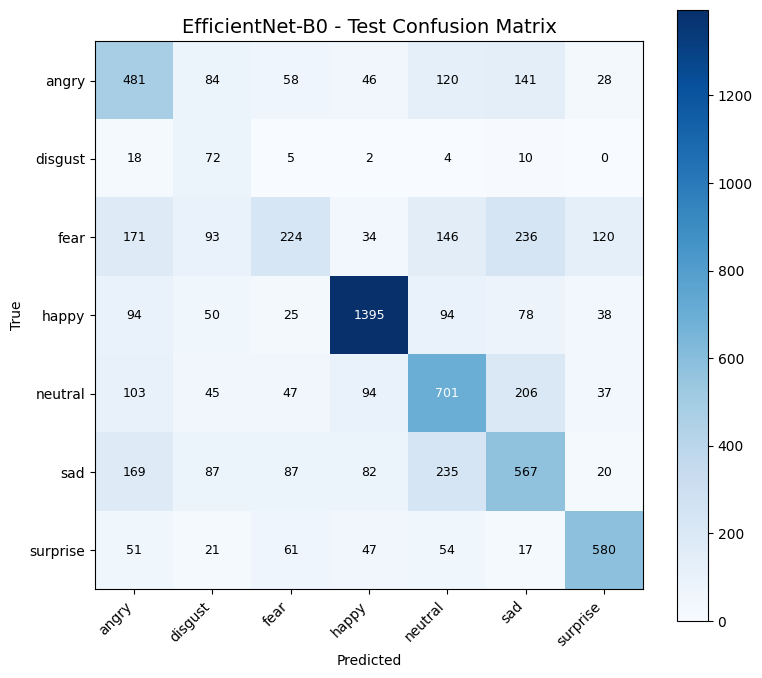

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/efficientnet_b0_metrics.json
Per-class metrics saved -> /content/drive/MyDrive/emotion_project/outputs/metrics/efficientnet_b0_per_class_metrics.csv


In [ ]:
def evaluate_efficientnet_model(model, loader, device, class_names, model_name='EfficientNet'):
    """Evaluate EfficientNet and return summary metrics, predictions, and per-class results."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    report_text = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0,
    )
    report_dict = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(all_labels, all_preds)

    per_class_rows = []
    for idx, class_name in enumerate(class_names):
        support = int(cm[idx].sum())
        class_acc = cm[idx, idx] / support if support else 0.0
        per_class_rows.append({
            'class': class_name,
            'accuracy': round(float(class_acc), 4),
            'f1': round(float(report_dict[class_name]['f1-score']), 4),
            'precision': round(float(report_dict[class_name]['precision']), 4),
            'recall': round(float(report_dict[class_name]['recall']), 4),
            'support': support,
        })
    per_class_df = pd.DataFrame(per_class_rows)

    metrics = {
        'model': model_name,
        'accuracy': round(float(acc), 4),
        'weighted_f1': round(float(weighted_f1), 4),
        'macro_f1': round(float(macro_f1), 4),
        'precision': round(float(precision), 4),
        'recall': round(float(recall), 4),
    }

    print(f"\n{'='*60}")
    print(f"  {model_name} - Test Evaluation")
    print(f"{'='*60}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Macro F1      : {macro_f1:.4f}")
    print(f"  Weighted F1   : {weighted_f1:.4f}")
    print(f"  Precision (w) : {precision:.4f}")
    print(f"  Recall (w)    : {recall:.4f}")
    print("\nFull classification report:")
    print(report_text)
    print("Per-class accuracy/F1:")
    print(per_class_df.to_string(index=False))

    return metrics, all_preds, all_labels, per_class_df, cm, report_text


# Load the best saved checkpoint before evaluating on the test set.
best_eff_checkpoint = torch.load(EFF_CHECKPOINT_PATH, map_location=device)
efficientnet_model.load_state_dict(best_eff_checkpoint['model_state_dict'])

best_eff_metrics = best_eff_checkpoint.get('best_metrics', {})
print(f"Loaded best checkpoint: {EFF_CHECKPOINT_PATH}")
print(f"Best validation weighted F1: {best_eff_metrics.get('val_weighted_f1', 0.0):.4f}")

efficientnet_metrics, efficientnet_preds, efficientnet_labels, efficientnet_per_class_df, efficientnet_cm, efficientnet_report = evaluate_efficientnet_model(
    efficientnet_model,
    eff_test_loader,
    device,
    CLASS_NAMES,
    model_name=f'{EFF_DISPLAY_NAME} Attempt',
)

efficientnet_metrics['val_acc'] = round(float(best_eff_metrics.get('val_acc', np.nan)), 4)
efficientnet_metrics['val_weighted_f1'] = round(float(best_eff_metrics.get('val_weighted_f1', np.nan)), 4)

plot_confusion_matrix(
    efficientnet_labels,
    efficientnet_preds,
    CLASS_NAMES,
    title=f'{EFF_DISPLAY_NAME} - Test Confusion Matrix',
    save_path=FIGURES_DIR / f'{EFFICIENTNET_VARIANT}_confusion.png',
)

save_metrics(efficientnet_metrics, METRICS_DIR / f'{EFFICIENTNET_VARIANT}_metrics.json')
efficientnet_per_class_df.to_csv(METRICS_DIR / f'{EFFICIENTNET_VARIANT}_per_class_metrics.csv', index=False)
print(f"Per-class metrics saved -> {METRICS_DIR / f'{EFFICIENTNET_VARIANT}_per_class_metrics.csv'}")

# Avoid duplicate EfficientNet rows if this cell is rerun.
all_results = [
    result for result in all_results
    if not str(result.get('model', '')).startswith('EfficientNet-B')
]
all_results.append(efficientnet_metrics)


### EfficientNet-B0 Attempt Notes

EfficientNet-B0 did not improve over ResNet-18 in the current run, so it is retained only as an attempted lightweight model. This is useful evidence for model selection: a model that is efficient for deployment is not automatically the best choice for FER-2013 accuracy.

The final improved pipeline below uses ConvNeXt-Tiny because it is a stronger modern CNN-style architecture and gives a better chance of improving over ResNet-18 while remaining practical for Colab Pro training and later Streamlit/webcam inference.


## Advanced Emotion Recognition Model: ConvNeXt-Tiny + TTA + Ensemble Option

ConvNeXt-Tiny is added as the main final improved model attempt. It is stronger than the small custom CNN, usually fine-tunes more reliably than EfficientNet-B0 on difficult image classification tasks, is stable on Colab Pro GPUs, and is still practical for a later Streamlit/image-upload/webcam emotion-recognition demo.

This section records the actual ConvNeXt run and reports the evaluation metrics produced by the notebook.


### ConvNeXt Data Pipeline and Imbalance Handling

FER-2013 images are grayscale 48x48, so the pipeline converts them to 3-channel RGB, resizes to 224x224, and applies ImageNet normalization. The training augmentations are stronger than the baseline but still emotion-safe: no aggressive cropping is used, so the face should stay visible.

For class imbalance, this section uses class-weighted cross-entropy with label smoothing. This is stable, simple to reproduce, and avoids over-sampling noisy minority-class examples too aggressively.


In [ ]:
# ConvNeXt-Tiny configuration and data pipeline
CONVNEXT_IMG_SIZE = 224
CONVNEXT_BATCH_SIZE = 64
CONVNEXT_NUM_WORKERS = NUM_WORKERS
CONVNEXT_CHECKPOINT_PATH = CHECKPOINT_DIR / 'convnext_tiny_best_weighted_f1.pth'

convnext_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONVNEXT_IMG_SIZE, CONVNEXT_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.20, contrast=0.20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.5, 2.0), value='random'),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

convnext_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONVNEXT_IMG_SIZE, CONVNEXT_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

(convnext_train_ds, convnext_val_ds, convnext_test_ds,
 convnext_train_loader, convnext_val_loader, convnext_test_loader) =     create_datasets_and_loaders(
        convnext_train_transform,
        convnext_test_transform,
        batch_size=CONVNEXT_BATCH_SIZE,
        num_workers=CONVNEXT_NUM_WORKERS,
    )

convnext_train_targets = get_targets(convnext_train_ds)
convnext_class_counts = Counter(convnext_train_targets)
convnext_total_samples = sum(convnext_class_counts.values())
convnext_class_weights = torch.tensor(
    [convnext_total_samples / (NUM_CLASSES * convnext_class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(device)

print(f"ConvNeXt Train samples : {len(convnext_train_ds)}")
print(f"ConvNeXt Val samples   : {len(convnext_val_ds)}")
print(f"ConvNeXt Test samples  : {len(convnext_test_ds)}")
print("ConvNeXt class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:>10s}: {convnext_class_weights[i]:.3f}")

images, labels = next(iter(convnext_train_loader))
print(f"Sample ConvNeXt batch  : images {images.shape}, labels {labels.shape}")


ConvNeXt Train samples : 22967
ConvNeXt Val samples   : 5742
ConvNeXt Test samples  : 7178
ConvNeXt class weights:
       angry: 1.022
     disgust: 9.348
        fear: 0.989
       happy: 0.570
     neutral: 0.820
         sad: 0.869
    surprise: 1.284
Sample ConvNeXt batch  : images torch.Size([64, 3, 224, 224]), labels torch.Size([64])


### ConvNeXt Model and Training Utilities

The ImageNet classifier is replaced with a dropout layer and a new 7-class linear head. Training is two-stage: first only the classifier head is trained, then the later ConvNeXt stages are unfrozen with a lower learning rate than the classifier head.


In [ ]:
def create_convnext_tiny(num_classes=7, dropout=0.40, pretrained=True, freeze_backbone=True):
    """Create a ConvNeXt-Tiny model with a FER-2013 classifier head."""
    weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.convnext_tiny(weights=weights)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


def set_convnext_feature_extraction(model):
    """Freeze the ConvNeXt feature extractor and train only the classifier."""
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True


def set_convnext_finetuning(model, unfreeze_from_stage=5):
    """Freeze early layers and unfreeze later ConvNeXt stages plus classifier."""
    for param in model.features.parameters():
        param.requires_grad = False

    for stage_idx, stage in enumerate(model.features):
        if stage_idx >= unfreeze_from_stage:
            for param in stage.parameters():
                param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True


def make_convnext_loss(weights, label_smoothing=0.05):
    """Class-weighted cross-entropy with label smoothing for stable imbalance handling."""
    try:
        return nn.CrossEntropyLoss(weight=weights, label_smoothing=label_smoothing)
    except TypeError:
        print("label_smoothing is unavailable in this PyTorch version; using weighted CE only.")
        return nn.CrossEntropyLoss(weight=weights)


def model_state_to_cpu(model):
    """Copy model state to CPU before checkpointing."""
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def run_convnext_epoch(model, loader, criterion, optimizer=None, scaler=None, use_amp=False):
    """Run one train/validation epoch and return loss, accuracy, macro F1, weighted F1."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    total = 0
    all_preds = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for group in optimizer.param_groups for p in group['params'] if p.grad is not None],
                    max_norm=1.0,
                )
                scaler.step(optimizer)
                scaler.update()

            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = running_loss / total
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, macro_f1, weighted_f1


def train_convnext_model(model, train_loader, val_loader, criterion, optimizer,
                         scheduler=None, epochs=20, checkpoint_path=None,
                         patience=6, min_delta=0.001, model_name='ConvNeXt-Tiny',
                         initial_best_metrics=None):
    """Train ConvNeXt with early stopping and checkpointing on validation weighted F1."""
    history = {
        'train_loss': [], 'train_acc': [], 'train_macro_f1': [], 'train_weighted_f1': [],
        'val_loss': [], 'val_acc': [], 'val_macro_f1': [], 'val_weighted_f1': [],
    }
    use_amp = (device.type == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_metrics = dict(initial_best_metrics) if initial_best_metrics else {'val_weighted_f1': -np.inf}
    best_score = best_metrics.get('val_weighted_f1', -np.inf)
    best_state = model_state_to_cpu(model)
    epochs_without_improvement = 0

    print(f"\n{'='*74}")
    print(f"  Training: {model_name}")
    print(f"  Mixed precision: {'enabled' if use_amp else 'disabled'}")
    print(f"{'='*74}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1, train_weighted_f1 = run_convnext_epoch(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler, use_amp=use_amp
        )
        val_loss, val_acc, val_macro_f1, val_weighted_f1 = run_convnext_epoch(
            model, val_loader, criterion, optimizer=None, scaler=None, use_amp=use_amp
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_macro_f1'].append(train_macro_f1)
        history['train_weighted_f1'].append(train_weighted_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_macro_f1)
        history['val_weighted_f1'].append(val_weighted_f1)

        if scheduler is not None:
            scheduler.step()

        improved = val_weighted_f1 > best_score + min_delta
        if improved:
            best_score = val_weighted_f1
            best_metrics = {
                'val_loss': val_loss,
                'val_acc': val_acc,
                'val_macro_f1': val_macro_f1,
                'val_weighted_f1': val_weighted_f1,
            }
            best_state = model_state_to_cpu(model)
            epochs_without_improvement = 0
            if checkpoint_path is not None:
                torch.save({
                    'model_name': 'ConvNeXt-Tiny',
                    'image_size': CONVNEXT_IMG_SIZE,
                    'class_names': CLASS_NAMES,
                    'model_state_dict': best_state,
                    'best_metrics': best_metrics,
                    'history': history,
                }, checkpoint_path)
        else:
            epochs_without_improvement += 1

        lr_summary = ', '.join(f"{group['lr']:.2e}" for group in optimizer.param_groups)
        print(
            f"  Epoch {epoch:>2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f} | "
            f"Val Weighted F1: {val_weighted_f1:.4f} | "
            f"LR: {lr_summary}"
        )

        if epochs_without_improvement >= patience:
            print(f"  Early stopping: validation weighted F1 did not improve for {patience} epochs.")
            break

    model.load_state_dict(best_state)
    print(f"\n  Best validation weighted F1: {best_metrics.get('val_weighted_f1', 0.0):.4f}")
    return history, best_metrics


### ConvNeXt Feature Extraction

First, freeze the ConvNeXt backbone and train only the new classifier head. This gives the head a stable starting point before fine-tuning pretrained stages.


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 254MB/s] 


ConvNeXt-Tiny Feature Extraction
  Trainable params : 6,919 / 27,825,511

  Training: ConvNeXt-Tiny (Feature Extraction)
  Mixed precision: enabled
  Epoch  1/5 | Train Loss: 1.8408 | Val Loss: 1.7374 | Val Acc: 0.4626 | Val Macro F1: 0.4058 | Val Weighted F1: 0.4610 | LR: 9.05e-04
  Epoch  2/5 | Train Loss: 1.7296 | Val Loss: 1.6841 | Val Acc: 0.4794 | Val Macro F1: 0.4161 | Val Weighted F1: 0.4742 | LR: 6.55e-04
  Epoch  3/5 | Train Loss: 1.7106 | Val Loss: 1.6635 | Val Acc: 0.4636 | Val Macro F1: 0.4019 | Val Weighted F1: 0.4615 | LR: 3.45e-04
  Epoch  4/5 | Train Loss: 1.6913 | Val Loss: 1.6514 | Val Acc: 0.4732 | Val Macro F1: 0.4191 | Val Weighted F1: 0.4750 | LR: 9.55e-05
  Epoch  5/5 | Train Loss: 1.6779 | Val Loss: 1.6396 | Val Acc: 0.4775 | Val Macro F1: 0.4256 | Val Weighted F1: 0.4833 | LR: 0.00e+00

  Best validation weighted F1: 0.4833


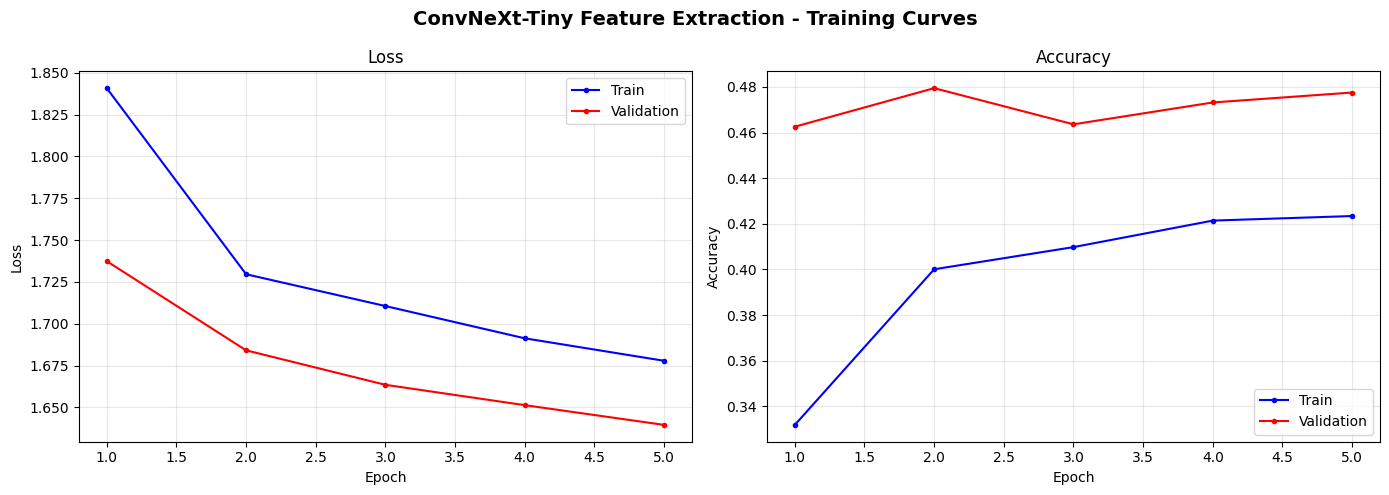

In [ ]:
# ConvNeXt feature extraction
CONVNEXT_FE_EPOCHS = 5
CONVNEXT_FE_LR = 1e-3
CONVNEXT_WEIGHT_DECAY = 1e-4
CONVNEXT_LABEL_SMOOTHING = 0.05
CONVNEXT_PATIENCE = 6

set_seed(42)
convnext_model = create_convnext_tiny(
    num_classes=NUM_CLASSES,
    dropout=0.40,
    pretrained=True,
    freeze_backbone=True,
).to(device)
set_convnext_feature_extraction(convnext_model)

trainable, total = count_parameters(convnext_model)
print("ConvNeXt-Tiny Feature Extraction")
print(f"  Trainable params : {trainable:,} / {total:,}")

convnext_criterion = make_convnext_loss(
    convnext_class_weights,
    label_smoothing=CONVNEXT_LABEL_SMOOTHING,
)
convnext_fe_optimizer = optim.AdamW(
    convnext_model.classifier.parameters(),
    lr=CONVNEXT_FE_LR,
    weight_decay=CONVNEXT_WEIGHT_DECAY,
)
convnext_fe_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    convnext_fe_optimizer,
    T_max=CONVNEXT_FE_EPOCHS,
)

convnext_fe_history, convnext_best_metrics = train_convnext_model(
    convnext_model,
    convnext_train_loader,
    convnext_val_loader,
    convnext_criterion,
    convnext_fe_optimizer,
    scheduler=convnext_fe_scheduler,
    epochs=CONVNEXT_FE_EPOCHS,
    checkpoint_path=CONVNEXT_CHECKPOINT_PATH,
    patience=CONVNEXT_PATIENCE,
    model_name='ConvNeXt-Tiny (Feature Extraction)',
)

plot_training_curves(
    convnext_fe_history,
    title='ConvNeXt-Tiny Feature Extraction - Training Curves',
    save_path=FIGURES_DIR / 'convnext_tiny_feature_extract_curves.png',
)


### ConvNeXt Fine-Tuning

The best feature-extraction checkpoint is loaded, then the later ConvNeXt stages are unfrozen. Pretrained backbone parameters use a lower learning rate, while the classifier head uses a higher learning rate.


ConvNeXt-Tiny Fine-Tuning
  Unfrozen feature stages from index : 5
  Trainable params                   : 26,294,791 / 27,825,511

  Training: ConvNeXt-Tiny (Fine-Tuning)
  Mixed precision: enabled
  Epoch  1/25 | Train Loss: 1.5991 | Val Loss: 1.5135 | Val Acc: 0.5082 | Val Macro F1: 0.4560 | Val Weighted F1: 0.5257 | LR: 9.96e-06, 2.99e-04
  Epoch  2/25 | Train Loss: 1.4917 | Val Loss: 1.4447 | Val Acc: 0.5566 | Val Macro F1: 0.4973 | Val Weighted F1: 0.5613 | LR: 9.84e-06, 2.95e-04
  Epoch  3/25 | Train Loss: 1.4221 | Val Loss: 1.3974 | Val Acc: 0.5897 | Val Macro F1: 0.5299 | Val Weighted F1: 0.5927 | LR: 9.65e-06, 2.89e-04
  Epoch  4/25 | Train Loss: 1.3669 | Val Loss: 1.3744 | Val Acc: 0.5921 | Val Macro F1: 0.5361 | Val Weighted F1: 0.6006 | LR: 9.38e-06, 2.81e-04
  Epoch  5/25 | Train Loss: 1.3313 | Val Loss: 1.3468 | Val Acc: 0.6029 | Val Macro F1: 0.5424 | Val Weighted F1: 0.6030 | LR: 9.05e-06, 2.71e-04
  Epoch  6/25 | Train Loss: 1.2937 | Val Loss: 1.3230 | Val Acc: 0.6132 

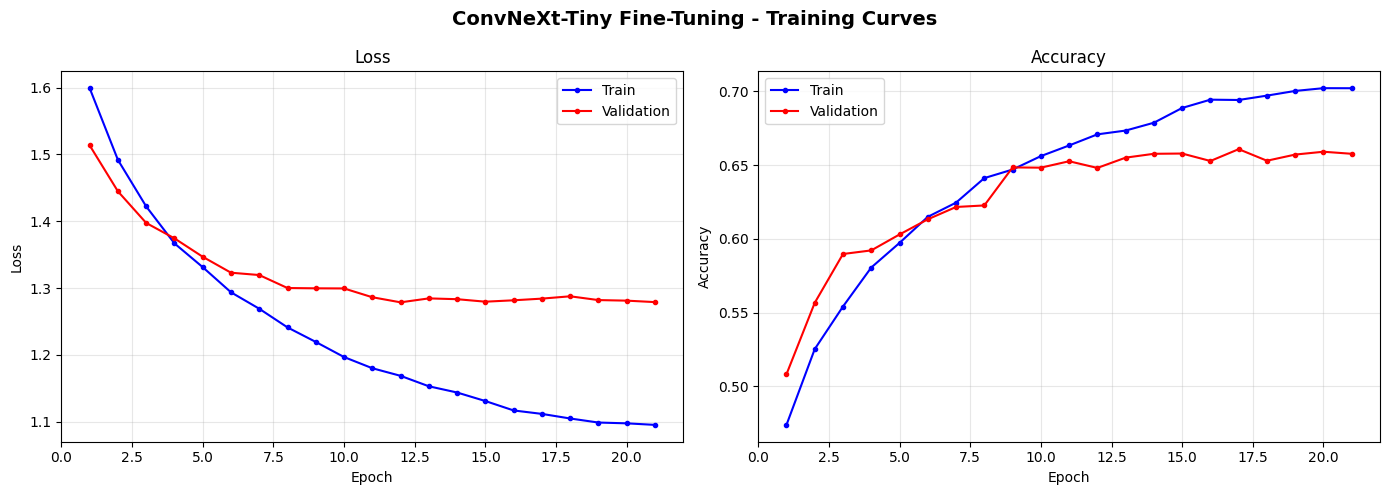

In [ ]:
# ConvNeXt fine-tuning
CONVNEXT_FT_EPOCHS = 25
CONVNEXT_LR_BACKBONE = 1e-5
CONVNEXT_LR_HEAD = 3e-4
CONVNEXT_UNFREEZE_FROM_STAGE = 5

convnext_checkpoint = torch.load(CONVNEXT_CHECKPOINT_PATH, map_location=device)
convnext_model.load_state_dict(convnext_checkpoint['model_state_dict'])
set_convnext_finetuning(convnext_model, unfreeze_from_stage=CONVNEXT_UNFREEZE_FROM_STAGE)

trainable, total = count_parameters(convnext_model)
print("ConvNeXt-Tiny Fine-Tuning")
print(f"  Unfrozen feature stages from index : {CONVNEXT_UNFREEZE_FROM_STAGE}")
print(f"  Trainable params                   : {trainable:,} / {total:,}")

convnext_backbone_params = [
    param for name, param in convnext_model.named_parameters()
    if param.requires_grad and name.startswith('features')
]
convnext_head_params = [
    param for name, param in convnext_model.named_parameters()
    if param.requires_grad and name.startswith('classifier')
]

convnext_param_groups = []
if convnext_backbone_params:
    convnext_param_groups.append({'params': convnext_backbone_params, 'lr': CONVNEXT_LR_BACKBONE})
if convnext_head_params:
    convnext_param_groups.append({'params': convnext_head_params, 'lr': CONVNEXT_LR_HEAD})

convnext_ft_optimizer = optim.AdamW(
    convnext_param_groups,
    weight_decay=CONVNEXT_WEIGHT_DECAY,
)
convnext_ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    convnext_ft_optimizer,
    T_max=CONVNEXT_FT_EPOCHS,
)

convnext_ft_history, convnext_best_metrics = train_convnext_model(
    convnext_model,
    convnext_train_loader,
    convnext_val_loader,
    convnext_criterion,
    convnext_ft_optimizer,
    scheduler=convnext_ft_scheduler,
    epochs=CONVNEXT_FT_EPOCHS,
    checkpoint_path=CONVNEXT_CHECKPOINT_PATH,
    patience=CONVNEXT_PATIENCE,
    model_name='ConvNeXt-Tiny (Fine-Tuning)',
    initial_best_metrics=convnext_best_metrics,
)

plot_training_curves(
    convnext_ft_history,
    title='ConvNeXt-Tiny Fine-Tuning - Training Curves',
    save_path=FIGURES_DIR / 'convnext_tiny_finetune_curves.png',
)


### ConvNeXt Test Evaluation

Before testing, load the best ConvNeXt checkpoint saved by validation weighted F1. This keeps the test result tied to the best validation checkpoint, not the last epoch.


Loaded best ConvNeXt checkpoint: /content/drive/MyDrive/emotion_project/outputs/checkpoints/convnext_tiny_best_weighted_f1.pth
Best validation weighted F1: 0.6587

  ConvNeXt-Tiny - Evaluation
  Accuracy      : 0.6647
  Macro F1      : 0.6305
  Weighted F1   : 0.6642
  Precision (w) : 0.6671
  Recall (w)    : 0.6647

Classification report:
              precision    recall  f1-score   support

       angry       0.59      0.60      0.59       958
     disgust       0.39      0.74      0.51       111
        fear       0.53      0.46      0.49      1024
       happy       0.89      0.86      0.88      1774
     neutral       0.61      0.65      0.63      1233
         sad       0.55      0.52      0.53      1247
    surprise       0.75      0.81      0.78       831

    accuracy                           0.66      7178
   macro avg       0.62      0.66      0.63      7178
weighted avg       0.67      0.66      0.66      7178

Per-class accuracy/F1:
   class  accuracy     f1  precision  

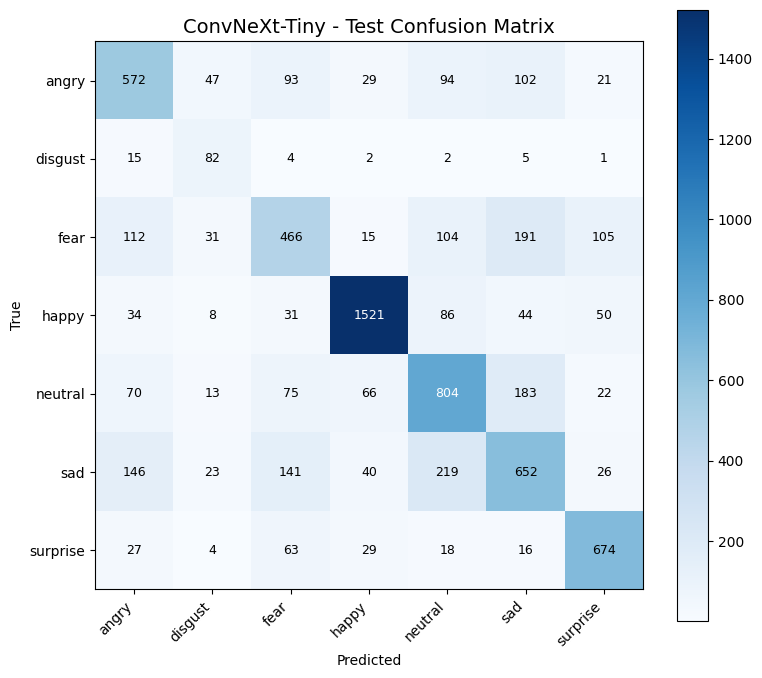

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/convnext_tiny_metrics.json


In [ ]:
def classification_metrics_from_predictions(y_true, y_pred, class_names, model_name):
    """Compute summary metrics, classification report, confusion matrix, and per-class rows."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    report_text = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred)

    per_class_rows = []
    for idx, class_name in enumerate(class_names):
        support = int(cm[idx].sum())
        class_acc = cm[idx, idx] / support if support else 0.0
        per_class_rows.append({
            'class': class_name,
            'accuracy': round(float(class_acc), 4),
            'f1': round(float(report_dict[class_name]['f1-score']), 4),
            'precision': round(float(report_dict[class_name]['precision']), 4),
            'recall': round(float(report_dict[class_name]['recall']), 4),
            'support': support,
        })
    per_class_df = pd.DataFrame(per_class_rows)

    metrics = {
        'model': model_name,
        'accuracy': round(float(acc), 4),
        'weighted_f1': round(float(weighted_f1), 4),
        'macro_f1': round(float(macro_f1), 4),
        'precision': round(float(precision), 4),
        'recall': round(float(recall), 4),
    }

    print(f"\n{'='*62}")
    print(f"  {model_name} - Evaluation")
    print(f"{'='*62}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  Macro F1      : {macro_f1:.4f}")
    print(f"  Weighted F1   : {weighted_f1:.4f}")
    print(f"  Precision (w) : {precision:.4f}")
    print(f"  Recall (w)    : {recall:.4f}")
    print("\nClassification report:")
    print(report_text)
    print("Per-class accuracy/F1:")
    print(per_class_df.to_string(index=False))

    return metrics, per_class_df, cm, report_text


def predict_probabilities(model, loader, use_tta=False):
    """Predict probabilities, optionally averaging simple test-time augmentations."""
    model.eval()
    all_probs = []
    all_labels = []
    use_amp = (device.type == 'cuda')

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if use_tta:
                variants = [
                    images,
                    torch.flip(images, dims=[3]),
                    adjust_brightness_contrast_batch(images, brightness=1.06, contrast=1.06),
                ]
            else:
                variants = [images]

            probs_sum = None
            for batch in variants:
                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model(batch)
                    probs = torch.softmax(logits, dim=1)
                probs_sum = probs if probs_sum is None else probs_sum + probs

            probs_avg = probs_sum / len(variants)
            all_probs.append(probs_avg.detach().cpu())
            all_labels.extend(labels.detach().cpu().numpy())

    return torch.cat(all_probs, dim=0).numpy(), np.array(all_labels)


def evaluate_probabilities(probs, labels, class_names, model_name):
    """Evaluate precomputed class probabilities."""
    preds = np.argmax(probs, axis=1)
    metrics, per_class_df, cm, report_text = classification_metrics_from_predictions(
        labels,
        preds,
        class_names,
        model_name,
    )
    return metrics, preds, labels, per_class_df, cm, report_text


best_convnext_checkpoint = torch.load(CONVNEXT_CHECKPOINT_PATH, map_location=device)
convnext_model.load_state_dict(best_convnext_checkpoint['model_state_dict'])
best_convnext_metrics = best_convnext_checkpoint.get('best_metrics', {})
print(f"Loaded best ConvNeXt checkpoint: {CONVNEXT_CHECKPOINT_PATH}")
print(f"Best validation weighted F1: {best_convnext_metrics.get('val_weighted_f1', 0.0):.4f}")

convnext_probs, convnext_labels = predict_probabilities(
    convnext_model,
    convnext_test_loader,
    use_tta=False,
)
convnext_metrics, convnext_preds, convnext_labels, convnext_per_class_df, convnext_cm, convnext_report = evaluate_probabilities(
    convnext_probs,
    convnext_labels,
    CLASS_NAMES,
    model_name='ConvNeXt-Tiny',
)
convnext_metrics['val_acc'] = round(float(best_convnext_metrics.get('val_acc', np.nan)), 4)
convnext_metrics['val_weighted_f1'] = round(float(best_convnext_metrics.get('val_weighted_f1', np.nan)), 4)

plot_confusion_matrix(
    convnext_labels,
    convnext_preds,
    CLASS_NAMES,
    title='ConvNeXt-Tiny - Test Confusion Matrix',
    save_path=FIGURES_DIR / 'convnext_tiny_confusion.png',
)

save_metrics(convnext_metrics, METRICS_DIR / 'convnext_tiny_metrics.json')
convnext_per_class_df.to_csv(METRICS_DIR / 'convnext_tiny_per_class_metrics.csv', index=False)

all_results = [result for result in all_results if result.get('model') != 'ConvNeXt-Tiny']
all_results.append(convnext_metrics)


### Test-Time Augmentation Evaluation

TTA averages predicted probabilities from the original image, a horizontally flipped image, and a lightly brightness/contrast adjusted version. This can improve robustness without retraining. The TTA score should be reported separately from the normal single-pass ConvNeXt score.



  ConvNeXt-Tiny + TTA - Evaluation
  Accuracy      : 0.6675
  Macro F1      : 0.6325
  Weighted F1   : 0.6673
  Precision (w) : 0.6704
  Recall (w)    : 0.6675

Classification report:
              precision    recall  f1-score   support

       angry       0.60      0.59      0.60       958
     disgust       0.38      0.75      0.51       111
        fear       0.54      0.46      0.50      1024
       happy       0.89      0.86      0.87      1774
     neutral       0.61      0.65      0.63      1233
         sad       0.55      0.53      0.54      1247
    surprise       0.75      0.82      0.78       831

    accuracy                           0.67      7178
   macro avg       0.62      0.67      0.63      7178
weighted avg       0.67      0.67      0.67      7178

Per-class accuracy/F1:
   class  accuracy     f1  precision  recall  support
   angry    0.5929 0.5951     0.5973  0.5929      958
 disgust    0.7477 0.5061     0.3825  0.7477      111
    fear    0.4629 0.4969     0.5

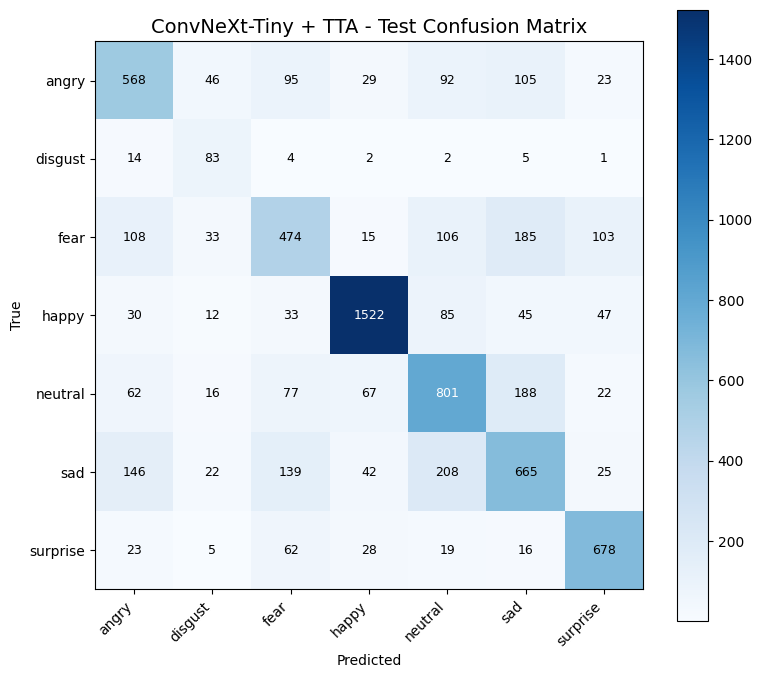

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/convnext_tiny_tta_metrics.json


In [ ]:
# Test-time augmentation helpers and evaluation
IMAGENET_MEAN_TENSOR = torch.tensor(IMAGENET_MEAN, dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD_TENSOR = torch.tensor(IMAGENET_STD, dtype=torch.float32).view(1, 3, 1, 1)


def denormalize_imagenet_batch(images):
    mean = IMAGENET_MEAN_TENSOR.to(images.device)
    std = IMAGENET_STD_TENSOR.to(images.device)
    return images * std + mean


def normalize_imagenet_batch(images):
    mean = IMAGENET_MEAN_TENSOR.to(images.device)
    std = IMAGENET_STD_TENSOR.to(images.device)
    return (images - mean) / std


def adjust_brightness_contrast_batch(images, brightness=1.06, contrast=1.06):
    """Apply a light brightness/contrast TTA transform to normalized tensors."""
    pixels = denormalize_imagenet_batch(images).clamp(0, 1)
    channel_mean = pixels.mean(dim=(2, 3), keepdim=True)
    pixels = (pixels - channel_mean) * contrast + channel_mean
    pixels = (pixels * brightness).clamp(0, 1)
    return normalize_imagenet_batch(pixels)


convnext_tta_probs, convnext_tta_labels = predict_probabilities(
    convnext_model,
    convnext_test_loader,
    use_tta=True,
)
convnext_tta_metrics, convnext_tta_preds, convnext_tta_labels, convnext_tta_per_class_df, convnext_tta_cm, convnext_tta_report = evaluate_probabilities(
    convnext_tta_probs,
    convnext_tta_labels,
    CLASS_NAMES,
    model_name='ConvNeXt-Tiny + TTA',
)
convnext_tta_metrics['val_acc'] = convnext_metrics.get('val_acc', np.nan)
convnext_tta_metrics['val_weighted_f1'] = convnext_metrics.get('val_weighted_f1', np.nan)

plot_confusion_matrix(
    convnext_tta_labels,
    convnext_tta_preds,
    CLASS_NAMES,
    title='ConvNeXt-Tiny + TTA - Test Confusion Matrix',
    save_path=FIGURES_DIR / 'convnext_tiny_tta_confusion.png',
)

save_metrics(convnext_tta_metrics, METRICS_DIR / 'convnext_tiny_tta_metrics.json')
convnext_tta_per_class_df.to_csv(METRICS_DIR / 'convnext_tiny_tta_per_class_metrics.csv', index=False)

all_results = [result for result in all_results if result.get('model') != 'ConvNeXt-Tiny + TTA']
all_results.append(convnext_tta_metrics)


### Optional Soft-Voting Ensemble

If both the ResNet-18 fine-tuning checkpoint and the ConvNeXt-Tiny checkpoint are available, this optional cell averages their predicted probabilities. It is designed not to break the notebook if either checkpoint is missing.



  ResNet-18 + ConvNeXt-Tiny Ensemble - Evaluation
  Accuracy      : 0.6819
  Macro F1      : 0.6561
  Weighted F1   : 0.6771
  Precision (w) : 0.6814
  Recall (w)    : 0.6819

Classification report:
              precision    recall  f1-score   support

       angry       0.63      0.59      0.61       958
     disgust       0.52      0.78      0.63       111
        fear       0.60      0.41      0.49      1024
       happy       0.87      0.90      0.88      1774
     neutral       0.66      0.61      0.64      1233
         sad       0.53      0.62      0.57      1247
    surprise       0.73      0.85      0.78       831

    accuracy                           0.68      7178
   macro avg       0.65      0.68      0.66      7178
weighted avg       0.68      0.68      0.68      7178

Per-class accuracy/F1:
   class  accuracy     f1  precision  recall  support
   angry    0.5908 0.6102     0.6310  0.5908      958
 disgust    0.7838 0.6259     0.5210  0.7838      111
    fear    0.4102

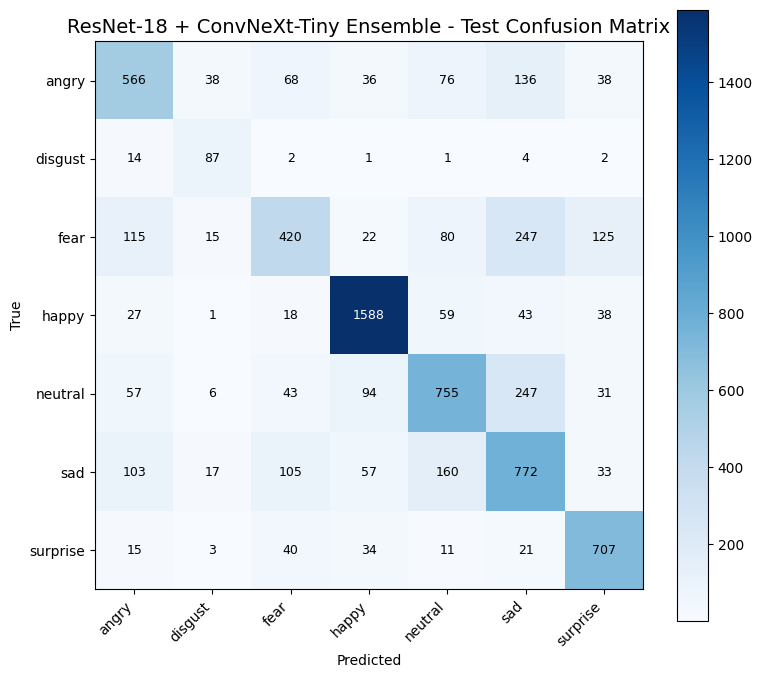

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/resnet18_convnext_ensemble_metrics.json


In [ ]:
# Optional ResNet-18 + ConvNeXt-Tiny soft-voting ensemble
RESNET18_FT_CHECKPOINT_PATH = CHECKPOINT_DIR / 'resnet18_finetune_best.pth'
ENSEMBLE_AVAILABLE = RESNET18_FT_CHECKPOINT_PATH.exists() and CONVNEXT_CHECKPOINT_PATH.exists()

if not ENSEMBLE_AVAILABLE:
    print("Optional ensemble skipped: one or both checkpoints are missing.")
    print(f"  ResNet-18 checkpoint : {RESNET18_FT_CHECKPOINT_PATH.exists()} ({RESNET18_FT_CHECKPOINT_PATH})")
    print(f"  ConvNeXt checkpoint  : {CONVNEXT_CHECKPOINT_PATH.exists()} ({CONVNEXT_CHECKPOINT_PATH})")
else:
    ensemble_resnet = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)
    resnet_state = torch.load(RESNET18_FT_CHECKPOINT_PATH, map_location=device)
    if isinstance(resnet_state, dict) and 'model_state_dict' in resnet_state:
        resnet_state = resnet_state['model_state_dict']
    ensemble_resnet.load_state_dict(resnet_state)
    ensemble_resnet.eval()

    ensemble_convnext = create_convnext_tiny(
        num_classes=NUM_CLASSES,
        dropout=0.40,
        pretrained=False,
        freeze_backbone=False,
    ).to(device)
    convnext_state = torch.load(CONVNEXT_CHECKPOINT_PATH, map_location=device)
    ensemble_convnext.load_state_dict(convnext_state['model_state_dict'])
    ensemble_convnext.eval()

    resnet_probs, ensemble_labels = predict_probabilities(
        ensemble_resnet,
        convnext_test_loader,
        use_tta=False,
    )
    convnext_probs_for_ensemble, _ = predict_probabilities(
        ensemble_convnext,
        convnext_test_loader,
        use_tta=True,
    )

    ensemble_probs = (resnet_probs + convnext_probs_for_ensemble) / 2.0
    ensemble_metrics, ensemble_preds, ensemble_labels, ensemble_per_class_df, ensemble_cm, ensemble_report = evaluate_probabilities(
        ensemble_probs,
        ensemble_labels,
        CLASS_NAMES,
        model_name='ResNet-18 + ConvNeXt-Tiny Ensemble',
    )

    plot_confusion_matrix(
        ensemble_labels,
        ensemble_preds,
        CLASS_NAMES,
        title='ResNet-18 + ConvNeXt-Tiny Ensemble - Test Confusion Matrix',
        save_path=FIGURES_DIR / 'resnet18_convnext_ensemble_confusion.png',
    )

    save_metrics(ensemble_metrics, METRICS_DIR / 'resnet18_convnext_ensemble_metrics.json')
    ensemble_per_class_df.to_csv(METRICS_DIR / 'resnet18_convnext_ensemble_per_class_metrics.csv', index=False)

    all_results = [
        result for result in all_results
        if result.get('model') != 'ResNet-18 + ConvNeXt-Tiny Ensemble'
    ]
    all_results.append(ensemble_metrics)


## Final Improvement Attempt: FERPlus-Style Cleaning + Strong Fine-Tuning

The current best result is the ResNet-18 + ConvNeXt-Tiny soft-voting ensemble at around 68% accuracy. ConvNeXt-Tiny and TTA are slightly better than ResNet-18, while EfficientNet-B0 underperformed. Instead of adding more architectures, this final attempt targets a likely bottleneck in FER-2013: noisy labels and ambiguous expressions.

FERPlus-style cleaning means using a strong trained model to identify training images whose given label strongly disagrees with the model prediction. Only the most suspicious training samples are removed. Validation and test data are never changed, so final metrics still reflect the original benchmark split.


### Identify Possible Noisy Training Labels

This pass uses the best ConvNeXt-Tiny checkpoint to score the training set with clean preprocessing. Samples are marked suspicious only when the model disagrees with the label and its confidence is high. The cleaned subset removes at most a small fraction of training images, so this is conservative label-noise handling rather than relabeling or changing the benchmark.


In [ ]:
# FERPlus-style label-noise detection setup
CLEANING_REMOVE_FRACTION = 0.07   # remove at most the top 7% most suspicious training samples
CLEANING_MIN_CONFIDENCE = 0.80
CLEANED_CONVNEXT_CHECKPOINT_PATH = CHECKPOINT_DIR / 'convnext_tiny_cleaned_best_weighted_f1.pth'
CLEANED_RESNET18_CHECKPOINT_PATH = CHECKPOINT_DIR / 'resnet18_cleaned_best_weighted_f1.pth'
TRAIN_CLEANED_RESNET18 = True

cleaning_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONVNEXT_IMG_SIZE, CONVNEXT_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.22, contrast=0.22),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.18, scale=(0.02, 0.08), ratio=(0.5, 2.0), value='random'),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

cleaning_eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CONVNEXT_IMG_SIZE, CONVNEXT_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def create_cleaning_datasets(train_transform, eval_transform, val_split=0.2):
    """Create augmented train, clean train, validation, and test datasets with matching train indices."""
    train_path = splits_info['train']['path']
    test_path = splits_info['test']['path']

    test_ds = datasets.ImageFolder(test_path, transform=eval_transform)

    if HAS_VAL:
        val_path = splits_info['val']['path']
        train_aug_ds = datasets.ImageFolder(train_path, transform=train_transform)
        train_clean_ds = datasets.ImageFolder(train_path, transform=eval_transform)
        val_ds = datasets.ImageFolder(val_path, transform=eval_transform)
    else:
        full_train_aug = datasets.ImageFolder(train_path, transform=train_transform)
        full_train_clean = datasets.ImageFolder(train_path, transform=eval_transform)

        n = len(full_train_aug)
        indices = list(range(n))
        set_seed(42)
        random.shuffle(indices)
        split_idx = int(n * (1 - val_split))
        train_indices = indices[:split_idx]
        val_indices = indices[split_idx:]

        train_aug_ds = Subset(full_train_aug, train_indices)
        train_clean_ds = Subset(full_train_clean, train_indices)
        val_ds = Subset(full_train_clean, val_indices)

    return train_aug_ds, train_clean_ds, val_ds, test_ds


def recursive_targets(dataset):
    """Return labels for ImageFolder/Subset, including nested Subset objects."""
    if isinstance(dataset, Subset):
        parent_targets = recursive_targets(dataset.dataset)
        return [parent_targets[i] for i in dataset.indices]
    if hasattr(dataset, 'targets'):
        return list(dataset.targets)
    return [label for _, label in dataset]


(cleaning_train_aug_ds, cleaning_train_clean_ds,
 cleaning_val_ds, cleaning_test_ds) = create_cleaning_datasets(
    cleaning_train_transform,
    cleaning_eval_transform,
)

cleaning_train_clean_loader = DataLoader(
    cleaning_train_clean_ds,
    batch_size=CONVNEXT_BATCH_SIZE,
    shuffle=False,
    num_workers=CONVNEXT_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
cleaning_val_loader = DataLoader(
    cleaning_val_ds,
    batch_size=CONVNEXT_BATCH_SIZE,
    shuffle=False,
    num_workers=CONVNEXT_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
cleaning_test_loader = DataLoader(
    cleaning_test_ds,
    batch_size=CONVNEXT_BATCH_SIZE,
    shuffle=False,
    num_workers=CONVNEXT_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Cleaning train candidates : {len(cleaning_train_clean_ds)}")
print(f"Validation samples        : {len(cleaning_val_ds)}")
print(f"Test samples              : {len(cleaning_test_ds)}")


Cleaning train candidates : 22967
Validation samples        : 5742
Test samples              : 7178


In [ ]:
def identify_suspicious_samples(model, loader, min_confidence=0.80, max_remove_fraction=0.07):
    """Find high-confidence train-set disagreements without touching validation/test data."""
    model.eval()
    use_amp = (device.type == 'cuda')
    candidates = []
    offset = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(images)
                probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)

            for batch_idx in range(labels.size(0)):
                pred = int(preds[batch_idx].item())
                label = int(labels[batch_idx].item())
                conf = float(confs[batch_idx].item())
                if pred != label and conf >= min_confidence:
                    candidates.append({
                        'position': offset + batch_idx,
                        'true_label': label,
                        'pred_label': pred,
                        'confidence': conf,
                    })
            offset += labels.size(0)

    candidates = sorted(candidates, key=lambda row: row['confidence'], reverse=True)
    max_remove = int(len(loader.dataset) * max_remove_fraction)
    selected = candidates[:max_remove]
    remove_positions = {row['position'] for row in selected}

    summary_rows = []
    for row in selected:
        summary_rows.append({
            'position': row['position'],
            'true_label': CLASS_NAMES[row['true_label']],
            'pred_label': CLASS_NAMES[row['pred_label']],
            'confidence': round(row['confidence'], 4),
        })

    print(f"High-confidence disagreements found : {len(candidates)}")
    print(f"Samples selected for removal        : {len(selected)} / {len(loader.dataset)}")
    print(f"Removal fraction                    : {len(selected) / len(loader.dataset):.3%}")

    suspicious_df = pd.DataFrame(summary_rows)
    if not suspicious_df.empty:
        display(suspicious_df.head(20))
        suspicious_df.to_csv(METRICS_DIR / 'possible_noisy_training_labels.csv', index=False)
        print(f"Suspicious-label list saved -> {METRICS_DIR / 'possible_noisy_training_labels.csv'}")
    else:
        print("No samples met the confidence/disagreement threshold; cleaned subset keeps all training samples.")

    return remove_positions, suspicious_df


if not CONVNEXT_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CONVNEXT_CHECKPOINT_PATH}. Run the ConvNeXt-Tiny section before label-noise cleaning."
    )

noise_detector_model = create_convnext_tiny(
    num_classes=NUM_CLASSES,
    dropout=0.40,
    pretrained=False,
    freeze_backbone=False,
).to(device)
noise_detector_checkpoint = torch.load(CONVNEXT_CHECKPOINT_PATH, map_location=device)
noise_detector_model.load_state_dict(noise_detector_checkpoint['model_state_dict'])

remove_positions, suspicious_labels_df = identify_suspicious_samples(
    noise_detector_model,
    cleaning_train_clean_loader,
    min_confidence=CLEANING_MIN_CONFIDENCE,
    max_remove_fraction=CLEANING_REMOVE_FRACTION,
)

keep_positions = [
    idx for idx in range(len(cleaning_train_aug_ds))
    if idx not in remove_positions
]
cleaned_train_ds = Subset(cleaning_train_aug_ds, keep_positions)
cleaned_train_loader = DataLoader(
    cleaned_train_ds,
    batch_size=CONVNEXT_BATCH_SIZE,
    shuffle=True,
    num_workers=CONVNEXT_NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

cleaned_train_targets = recursive_targets(cleaned_train_ds)
cleaned_class_counts = Counter(cleaned_train_targets)
cleaned_total_samples = sum(cleaned_class_counts.values())
cleaned_class_weights = torch.tensor(
    [cleaned_total_samples / (NUM_CLASSES * cleaned_class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(device)

print(f"Original train samples : {len(cleaning_train_aug_ds)}")
print(f"Cleaned train samples  : {len(cleaned_train_ds)}")
print("Cleaned class weights:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:>10s}: {cleaned_class_weights[i]:.3f}")


High-confidence disagreements found : 237
Samples selected for removal        : 237 / 22967
Removal fraction                    : 1.032%


,position,true_label,pred_label,confidence
0,912,fear,disgust,0.9958
1,18153,fear,surprise,0.9749
2,20661,fear,surprise,0.9710
3,20043,fear,angry,0.9675
4,2727,fear,surprise,0.9666
5,6911,sad,happy,0.9660
6,9541,sad,disgust,0.9634
7,7934,angry,disgust,0.9571
8,13852,fear,angry,0.9559
9,8326,fear,angry,0.9508


Suspicious-label list saved -> /content/drive/MyDrive/emotion_project/outputs/metrics/possible_noisy_training_labels.csv
Original train samples : 22967
Cleaned train samples  : 22730
Cleaned class weights:
       angry: 1.021
     disgust: 9.251
        fear: 1.002
       happy: 0.567
     neutral: 0.820
         sad: 0.871
    surprise: 1.278


### Strong Fine-Tuning on the Cleaned Training Subset

The cleaned-data run starts from the previous best ConvNeXt-Tiny checkpoint and fine-tunes later stages with a conservative backbone learning rate. The classifier head gets a larger learning rate. AdamW, label smoothing, class-weighted loss, mixed precision, warmup, cosine decay, gradient clipping, and early stopping are used to reduce overfitting on the cleaned subset.


In [ ]:
def build_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warmup followed by cosine annealing; fallback to cosine if SequentialLR is unavailable."""
    warmup_epochs = max(1, min(warmup_epochs, total_epochs - 1))
    cosine_epochs = max(1, total_epochs - warmup_epochs)
    try:
        warmup = optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=0.10,
            end_factor=1.0,
            total_iters=warmup_epochs,
        )
        cosine = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_epochs,
        )
        return optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup, cosine],
            milestones=[warmup_epochs],
        )
    except AttributeError:
        print("SequentialLR/LinearLR unavailable; using CosineAnnealingLR without warmup.")
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)


def train_cleaned_model(model, train_loader, val_loader, criterion, optimizer,
                        scheduler=None, epochs=20, checkpoint_path=None,
                        patience=6, min_delta=0.001, model_name='Cleaned Model'):
    """Generic cleaned-data trainer with early stopping on validation weighted F1."""
    history = {
        'train_loss': [], 'train_acc': [], 'train_macro_f1': [], 'train_weighted_f1': [],
        'val_loss': [], 'val_acc': [], 'val_macro_f1': [], 'val_weighted_f1': [],
    }
    use_amp = (device.type == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    best_score = -np.inf
    best_state = model_state_to_cpu(model)
    best_metrics = {}
    epochs_without_improvement = 0

    print()
    print('=' * 76)
    print(f"  Training: {model_name}")
    print(f"  Mixed precision: {'enabled' if use_amp else 'disabled'}")
    print('=' * 76)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_macro_f1, train_weighted_f1 = run_convnext_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            scaler=scaler,
            use_amp=use_amp,
        )
        val_loss, val_acc, val_macro_f1, val_weighted_f1 = run_convnext_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            scaler=None,
            use_amp=use_amp,
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_macro_f1'].append(train_macro_f1)
        history['train_weighted_f1'].append(train_weighted_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_macro_f1)
        history['val_weighted_f1'].append(val_weighted_f1)

        if scheduler is not None:
            scheduler.step()

        improved = val_weighted_f1 > best_score + min_delta
        if improved:
            best_score = val_weighted_f1
            best_metrics = {
                'val_loss': val_loss,
                'val_acc': val_acc,
                'val_macro_f1': val_macro_f1,
                'val_weighted_f1': val_weighted_f1,
            }
            best_state = model_state_to_cpu(model)
            epochs_without_improvement = 0
            if checkpoint_path is not None:
                torch.save({
                    'model_name': model_name,
                    'image_size': CONVNEXT_IMG_SIZE,
                    'class_names': CLASS_NAMES,
                    'removed_training_samples': len(remove_positions),
                    'model_state_dict': best_state,
                    'best_metrics': best_metrics,
                    'history': history,
                }, checkpoint_path)
        else:
            epochs_without_improvement += 1

        lr_summary = ', '.join(f"{group['lr']:.2e}" for group in optimizer.param_groups)
        print(
            f"  Epoch {epoch:>2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro F1: {val_macro_f1:.4f} | "
            f"Val Weighted F1: {val_weighted_f1:.4f} | "
            f"LR: {lr_summary}"
        )

        if epochs_without_improvement >= patience:
            print(f"  Early stopping: validation weighted F1 did not improve for {patience} epochs.")
            break

    model.load_state_dict(best_state)
    print(f"Best validation weighted F1: {best_metrics.get('val_weighted_f1', 0.0):.4f}")
    return history, best_metrics


Cleaned-data ConvNeXt-Tiny
  Trainable params : 26,590,471 / 27,825,511
  Removed samples  : 237

  Training: Cleaned-data ConvNeXt-Tiny
  Mixed precision: enabled
  Epoch  1/25 | Train Loss: 1.2618 | Val Loss: 1.4154 | Val Acc: 0.6546 | Val Macro F1: 0.6075 | Val Weighted F1: 0.6554 | LR: 2.00e-06, 4.00e-05
  Epoch  2/25 | Train Loss: 1.2634 | Val Loss: 1.4103 | Val Acc: 0.6533 | Val Macro F1: 0.6048 | Val Weighted F1: 0.6536 | LR: 3.50e-06, 7.00e-05
  Epoch  3/25 | Train Loss: 1.2617 | Val Loss: 1.4082 | Val Acc: 0.6548 | Val Macro F1: 0.6085 | Val Weighted F1: 0.6542 | LR: 5.00e-06, 1.00e-04
  Epoch  4/25 | Train Loss: 1.2550 | Val Loss: 1.4071 | Val Acc: 0.6491 | Val Macro F1: 0.5999 | Val Weighted F1: 0.6516 | LR: 4.97e-06, 9.95e-05
  Epoch  5/25 | Train Loss: 1.2463 | Val Loss: 1.4064 | Val Acc: 0.6527 | Val Macro F1: 0.6064 | Val Weighted F1: 0.6539 | LR: 4.90e-06, 9.80e-05
  Epoch  6/25 | Train Loss: 1.2349 | Val Loss: 1.4005 | Val Acc: 0.6543 | Val Macro F1: 0.6038 | Val Weigh

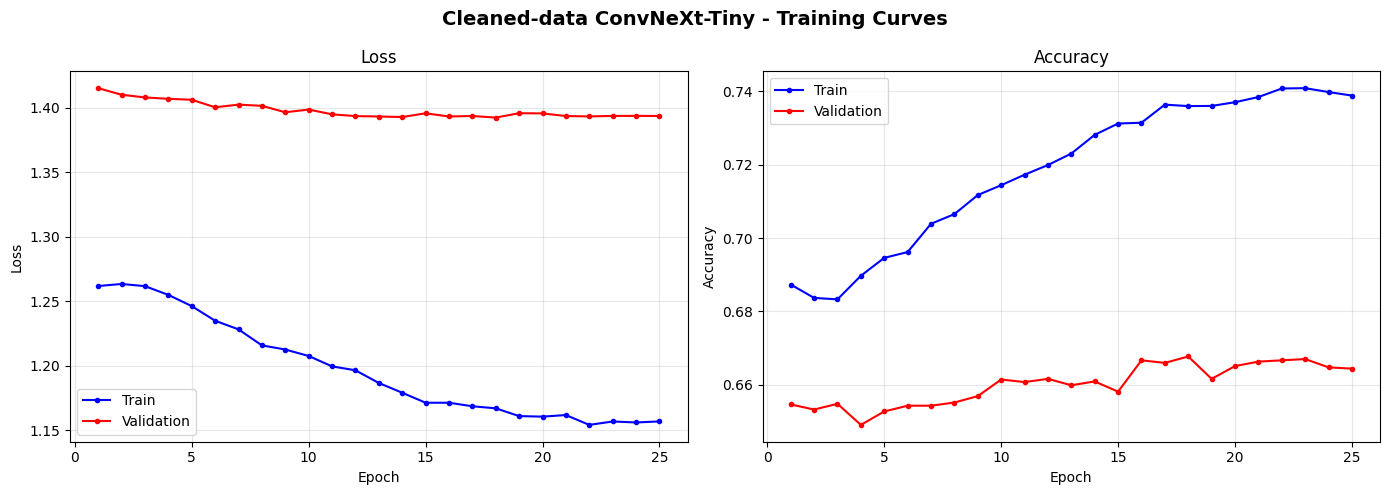

In [ ]:
# Fine-tune ConvNeXt-Tiny on the cleaned subset
CLEANED_CONVNEXT_EPOCHS = 25
CLEANED_CONVNEXT_WARMUP_EPOCHS = 3
CLEANED_CONVNEXT_LR_BACKBONE = 5e-6
CLEANED_CONVNEXT_LR_HEAD = 1e-4
CLEANED_CONVNEXT_WEIGHT_DECAY = 2e-4
CLEANED_CONVNEXT_LABEL_SMOOTHING = 0.08
CLEANED_CONVNEXT_PATIENCE = 7
CLEANED_CONVNEXT_UNFREEZE_FROM_STAGE = 4

set_seed(42)
cleaned_convnext_model = create_convnext_tiny(
    num_classes=NUM_CLASSES,
    dropout=0.45,
    pretrained=False,
    freeze_backbone=False,
).to(device)
base_convnext_checkpoint = torch.load(CONVNEXT_CHECKPOINT_PATH, map_location=device)
cleaned_convnext_model.load_state_dict(base_convnext_checkpoint['model_state_dict'])
set_convnext_finetuning(
    cleaned_convnext_model,
    unfreeze_from_stage=CLEANED_CONVNEXT_UNFREEZE_FROM_STAGE,
)

cleaned_convnext_backbone_params = [
    param for name, param in cleaned_convnext_model.named_parameters()
    if param.requires_grad and name.startswith('features')
]
cleaned_convnext_head_params = [
    param for name, param in cleaned_convnext_model.named_parameters()
    if param.requires_grad and name.startswith('classifier')
]

cleaned_convnext_optimizer = optim.AdamW(
    [
        {'params': cleaned_convnext_backbone_params, 'lr': CLEANED_CONVNEXT_LR_BACKBONE},
        {'params': cleaned_convnext_head_params, 'lr': CLEANED_CONVNEXT_LR_HEAD},
    ],
    weight_decay=CLEANED_CONVNEXT_WEIGHT_DECAY,
)
cleaned_convnext_scheduler = build_warmup_cosine_scheduler(
    cleaned_convnext_optimizer,
    warmup_epochs=CLEANED_CONVNEXT_WARMUP_EPOCHS,
    total_epochs=CLEANED_CONVNEXT_EPOCHS,
)
cleaned_convnext_criterion = make_convnext_loss(
    cleaned_class_weights,
    label_smoothing=CLEANED_CONVNEXT_LABEL_SMOOTHING,
)

trainable, total = count_parameters(cleaned_convnext_model)
print("Cleaned-data ConvNeXt-Tiny")
print(f"  Trainable params : {trainable:,} / {total:,}")
print(f"  Removed samples  : {len(remove_positions)}")

cleaned_convnext_history, cleaned_convnext_best_metrics = train_cleaned_model(
    cleaned_convnext_model,
    cleaned_train_loader,
    cleaning_val_loader,
    cleaned_convnext_criterion,
    cleaned_convnext_optimizer,
    scheduler=cleaned_convnext_scheduler,
    epochs=CLEANED_CONVNEXT_EPOCHS,
    checkpoint_path=CLEANED_CONVNEXT_CHECKPOINT_PATH,
    patience=CLEANED_CONVNEXT_PATIENCE,
    model_name='Cleaned-data ConvNeXt-Tiny',
)

plot_training_curves(
    cleaned_convnext_history,
    title='Cleaned-data ConvNeXt-Tiny - Training Curves',
    save_path=FIGURES_DIR / 'cleaned_convnext_tiny_curves.png',
)


### Optional Cleaned-Data ResNet-18 Fine-Tuning

ConvNeXt-Tiny remains the main cleaned-data model. This optional block allows ResNet-18 to be fine-tuned on the same cleaned subset if its checkpoint is available, which can support a cleaned-data ensemble without introducing another architecture.


In [ ]:
# Optional cleaned-data ResNet-18 fine-tuning
RESNET18_FT_CHECKPOINT_PATH = CHECKPOINT_DIR / 'resnet18_finetune_best.pth'

if not TRAIN_CLEANED_RESNET18:
    print("Cleaned-data ResNet-18 fine-tuning skipped by configuration.")
elif not RESNET18_FT_CHECKPOINT_PATH.exists():
    print(f"Cleaned-data ResNet-18 skipped: missing {RESNET18_FT_CHECKPOINT_PATH}")
else:
    CLEANED_RESNET_EPOCHS = 15
    CLEANED_RESNET_WARMUP_EPOCHS = 2
    CLEANED_RESNET_LR_BACKBONE = 1e-5
    CLEANED_RESNET_LR_HEAD = 2e-4
    CLEANED_RESNET_WEIGHT_DECAY = 2e-4

    cleaned_resnet_model = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)
    resnet_checkpoint = torch.load(RESNET18_FT_CHECKPOINT_PATH, map_location=device)
    if isinstance(resnet_checkpoint, dict) and 'model_state_dict' in resnet_checkpoint:
        resnet_checkpoint = resnet_checkpoint['model_state_dict']
    cleaned_resnet_model.load_state_dict(resnet_checkpoint)

    for name, param in cleaned_resnet_model.named_parameters():
        param.requires_grad = any(part in name for part in ['layer3', 'layer4', 'fc'])

    cleaned_resnet_optimizer = optim.AdamW(
        [
            {'params': cleaned_resnet_model.layer3.parameters(), 'lr': CLEANED_RESNET_LR_BACKBONE},
            {'params': cleaned_resnet_model.layer4.parameters(), 'lr': CLEANED_RESNET_LR_BACKBONE},
            {'params': cleaned_resnet_model.fc.parameters(), 'lr': CLEANED_RESNET_LR_HEAD},
        ],
        weight_decay=CLEANED_RESNET_WEIGHT_DECAY,
    )
    cleaned_resnet_scheduler = build_warmup_cosine_scheduler(
        cleaned_resnet_optimizer,
        warmup_epochs=CLEANED_RESNET_WARMUP_EPOCHS,
        total_epochs=CLEANED_RESNET_EPOCHS,
    )
    cleaned_resnet_criterion = make_convnext_loss(
        cleaned_class_weights,
        label_smoothing=0.06,
    )

    trainable, total = count_parameters(cleaned_resnet_model)
    print("Cleaned-data ResNet-18 Fine-Tuning")
    print(f"  Trainable params : {trainable:,} / {total:,}")

    cleaned_resnet_history, cleaned_resnet_best_metrics = train_cleaned_model(
        cleaned_resnet_model,
        cleaned_train_loader,
        cleaning_val_loader,
        cleaned_resnet_criterion,
        cleaned_resnet_optimizer,
        scheduler=cleaned_resnet_scheduler,
        epochs=CLEANED_RESNET_EPOCHS,
        checkpoint_path=CLEANED_RESNET18_CHECKPOINT_PATH,
        patience=5,
        model_name='Cleaned-data ResNet-18',
    )


Cleaned-data ResNet-18 Fine-Tuning
  Trainable params : 10,497,031 / 11,180,103

  Training: Cleaned-data ResNet-18
  Mixed precision: enabled
  Epoch  1/15 | Train Loss: 1.8102 | Val Loss: 2.0596 | Val Acc: 0.6299 | Val Macro F1: 0.5943 | Val Weighted F1: 0.6341 | LR: 5.50e-06, 5.50e-06, 1.10e-04
  Epoch  2/15 | Train Loss: 1.3371 | Val Loss: 1.4428 | Val Acc: 0.6306 | Val Macro F1: 0.5788 | Val Weighted F1: 0.6382 | LR: 1.00e-05, 1.00e-05, 2.00e-04
  Epoch  3/15 | Train Loss: 1.1931 | Val Loss: 1.3658 | Val Acc: 0.6419 | Val Macro F1: 0.5909 | Val Weighted F1: 0.6487 | LR: 9.85e-06, 9.85e-06, 1.97e-04
  Epoch  4/15 | Train Loss: 1.1579 | Val Loss: 1.3615 | Val Acc: 0.6458 | Val Macro F1: 0.6027 | Val Weighted F1: 0.6513 | LR: 9.43e-06, 9.43e-06, 1.89e-04
  Epoch  5/15 | Train Loss: 1.1266 | Val Loss: 1.3591 | Val Acc: 0.6506 | Val Macro F1: 0.6050 | Val Weighted F1: 0.6518 | LR: 8.74e-06, 8.74e-06, 1.75e-04
  Epoch  6/15 | Train Loss: 1.1178 | Val Loss: 1.3426 | Val Acc: 0.6587 | Val

### Cleaned-Data Final Evaluation

The best cleaned ConvNeXt checkpoint is loaded before evaluation. Results are reported for normal inference, TTA, and a cleaned-data ensemble when the needed checkpoints exist. These metrics should be reported honestly even if cleaning does not improve over the previous ensemble.


Loaded cleaned ConvNeXt checkpoint: /content/drive/MyDrive/emotion_project/outputs/checkpoints/convnext_tiny_cleaned_best_weighted_f1.pth
Best validation weighted F1: 0.6691

  Cleaned-data ConvNeXt-Tiny - Evaluation
  Accuracy      : 0.6808
  Macro F1      : 0.6445
  Weighted F1   : 0.6806
  Precision (w) : 0.6858
  Recall (w)    : 0.6808

Classification report:
              precision    recall  f1-score   support

       angry       0.61      0.61      0.61       958
     disgust       0.37      0.77      0.50       111
        fear       0.57      0.48      0.52      1024
       happy       0.91      0.86      0.88      1774
     neutral       0.60      0.69      0.65      1233
         sad       0.58      0.52      0.55      1247
    surprise       0.77      0.84      0.80       831

    accuracy                           0.68      7178
   macro avg       0.63      0.68      0.64      7178
weighted avg       0.69      0.68      0.68      7178

Per-class accuracy/F1:
   class  accu

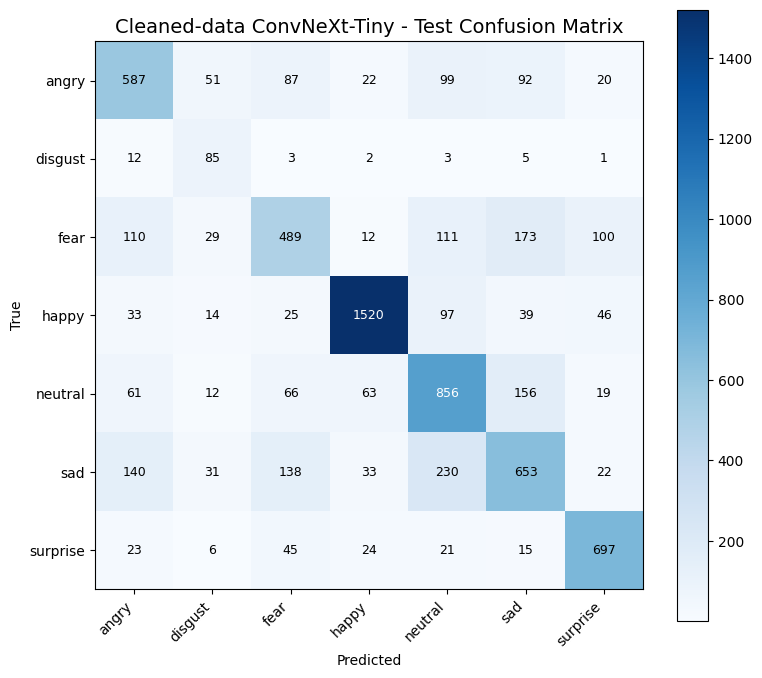

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/cleaned_convnext_tiny_metrics.json

  Cleaned-data ConvNeXt-Tiny + TTA - Evaluation
  Accuracy      : 0.6808
  Macro F1      : 0.6463
  Weighted F1   : 0.6800
  Precision (w) : 0.6846
  Recall (w)    : 0.6808

Classification report:
              precision    recall  f1-score   support

       angry       0.61      0.61      0.61       958
     disgust       0.39      0.77      0.52       111
        fear       0.57      0.47      0.52      1024
       happy       0.90      0.86      0.88      1774
     neutral       0.60      0.70      0.65      1233
         sad       0.57      0.52      0.55      1247
    surprise       0.77      0.84      0.80       831

    accuracy                           0.68      7178
   macro avg       0.63      0.68      0.65      7178
weighted avg       0.68      0.68      0.68      7178

Per-class accuracy/F1:
   class  accuracy     f1  precision  recall  support
   angry    0.6096 0

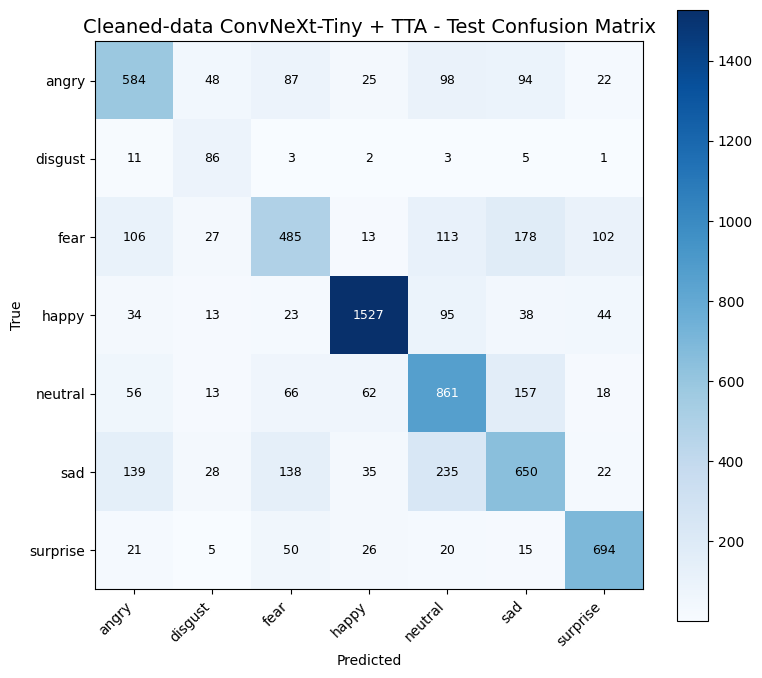

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/cleaned_convnext_tiny_tta_metrics.json


In [ ]:
# Cleaned-data ConvNeXt normal and TTA evaluation
best_cleaned_convnext_checkpoint = torch.load(CLEANED_CONVNEXT_CHECKPOINT_PATH, map_location=device)
cleaned_convnext_model.load_state_dict(best_cleaned_convnext_checkpoint['model_state_dict'])
cleaned_best_metrics = best_cleaned_convnext_checkpoint.get('best_metrics', {})
print(f"Loaded cleaned ConvNeXt checkpoint: {CLEANED_CONVNEXT_CHECKPOINT_PATH}")
print(f"Best validation weighted F1: {cleaned_best_metrics.get('val_weighted_f1', 0.0):.4f}")

cleaned_convnext_probs, cleaned_convnext_labels = predict_probabilities(
    cleaned_convnext_model,
    cleaning_test_loader,
    use_tta=False,
)
cleaned_convnext_metrics, cleaned_convnext_preds, cleaned_convnext_labels, cleaned_convnext_per_class_df, cleaned_convnext_cm, cleaned_convnext_report = evaluate_probabilities(
    cleaned_convnext_probs,
    cleaned_convnext_labels,
    CLASS_NAMES,
    model_name='Cleaned-data ConvNeXt-Tiny',
)
cleaned_convnext_metrics['val_acc'] = round(float(cleaned_best_metrics.get('val_acc', np.nan)), 4)
cleaned_convnext_metrics['val_weighted_f1'] = round(float(cleaned_best_metrics.get('val_weighted_f1', np.nan)), 4)

plot_confusion_matrix(
    cleaned_convnext_labels,
    cleaned_convnext_preds,
    CLASS_NAMES,
    title='Cleaned-data ConvNeXt-Tiny - Test Confusion Matrix',
    save_path=FIGURES_DIR / 'cleaned_convnext_tiny_confusion.png',
)
save_metrics(cleaned_convnext_metrics, METRICS_DIR / 'cleaned_convnext_tiny_metrics.json')
cleaned_convnext_per_class_df.to_csv(METRICS_DIR / 'cleaned_convnext_tiny_per_class_metrics.csv', index=False)

cleaned_convnext_tta_probs, cleaned_convnext_tta_labels = predict_probabilities(
    cleaned_convnext_model,
    cleaning_test_loader,
    use_tta=True,
)
cleaned_convnext_tta_metrics, cleaned_convnext_tta_preds, cleaned_convnext_tta_labels, cleaned_convnext_tta_per_class_df, cleaned_convnext_tta_cm, cleaned_convnext_tta_report = evaluate_probabilities(
    cleaned_convnext_tta_probs,
    cleaned_convnext_tta_labels,
    CLASS_NAMES,
    model_name='Cleaned-data ConvNeXt-Tiny + TTA',
)
cleaned_convnext_tta_metrics['val_acc'] = cleaned_convnext_metrics.get('val_acc', np.nan)
cleaned_convnext_tta_metrics['val_weighted_f1'] = cleaned_convnext_metrics.get('val_weighted_f1', np.nan)

plot_confusion_matrix(
    cleaned_convnext_tta_labels,
    cleaned_convnext_tta_preds,
    CLASS_NAMES,
    title='Cleaned-data ConvNeXt-Tiny + TTA - Test Confusion Matrix',
    save_path=FIGURES_DIR / 'cleaned_convnext_tiny_tta_confusion.png',
)
save_metrics(cleaned_convnext_tta_metrics, METRICS_DIR / 'cleaned_convnext_tiny_tta_metrics.json')
cleaned_convnext_tta_per_class_df.to_csv(METRICS_DIR / 'cleaned_convnext_tiny_tta_per_class_metrics.csv', index=False)

all_results = [
    result for result in all_results
    if result.get('model') not in ['Cleaned-data ConvNeXt-Tiny', 'Cleaned-data ConvNeXt-Tiny + TTA']
]
all_results.extend([cleaned_convnext_metrics, cleaned_convnext_tta_metrics])



  Cleaned-data Ensemble - Evaluation
  Accuracy      : 0.6970
  Macro F1      : 0.6627
  Weighted F1   : 0.6966
  Precision (w) : 0.7009
  Recall (w)    : 0.6970

Classification report:
              precision    recall  f1-score   support

       angry       0.63      0.63      0.63       958
     disgust       0.41      0.78      0.54       111
        fear       0.59      0.50      0.54      1024
       happy       0.91      0.87      0.89      1774
     neutral       0.63      0.70      0.66      1233
         sad       0.60      0.56      0.58      1247
    surprise       0.77      0.85      0.81       831

    accuracy                           0.70      7178
   macro avg       0.65      0.70      0.66      7178
weighted avg       0.70      0.70      0.70      7178

Per-class accuracy/F1:
   class  accuracy     f1  precision  recall  support
   angry    0.6284 0.6304     0.6324  0.6284      958
 disgust    0.7838 0.5354     0.4065  0.7838      111
    fear    0.4961 0.5376     0

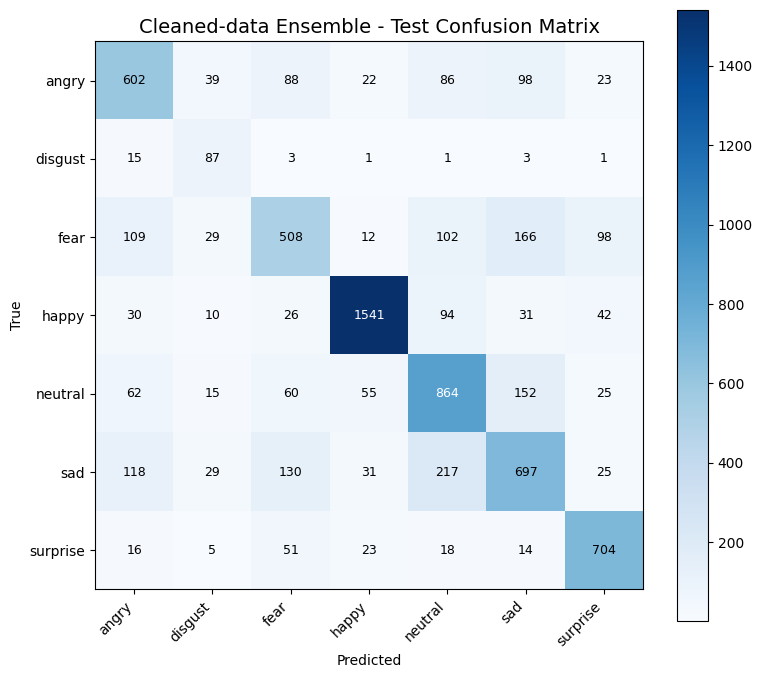

  Metrics saved → /content/drive/MyDrive/emotion_project/outputs/metrics/cleaned_data_ensemble_metrics.json
Cleaned-data ensemble used ResNet checkpoint: /content/drive/MyDrive/emotion_project/outputs/checkpoints/resnet18_cleaned_best_weighted_f1.pth


In [ ]:
# Cleaned-data ensemble evaluation if checkpoints exist
cleaned_ensemble_probs = None
cleaned_ensemble_labels = None
cleaned_ensemble_cm = None
cleaned_resnet_for_ensemble_path = None
if CLEANED_RESNET18_CHECKPOINT_PATH.exists():
    cleaned_resnet_for_ensemble_path = CLEANED_RESNET18_CHECKPOINT_PATH
elif RESNET18_FT_CHECKPOINT_PATH.exists():
    cleaned_resnet_for_ensemble_path = RESNET18_FT_CHECKPOINT_PATH

if cleaned_resnet_for_ensemble_path is None or not CLEANED_CONVNEXT_CHECKPOINT_PATH.exists():
    print("Cleaned-data ensemble skipped: required checkpoints are missing.")
else:
    cleaned_ensemble_resnet = create_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False).to(device)
    cleaned_resnet_state = torch.load(cleaned_resnet_for_ensemble_path, map_location=device)
    if isinstance(cleaned_resnet_state, dict) and 'model_state_dict' in cleaned_resnet_state:
        cleaned_resnet_state = cleaned_resnet_state['model_state_dict']
    cleaned_ensemble_resnet.load_state_dict(cleaned_resnet_state)
    cleaned_ensemble_resnet.eval()

    cleaned_ensemble_convnext = create_convnext_tiny(
        num_classes=NUM_CLASSES,
        dropout=0.45,
        pretrained=False,
        freeze_backbone=False,
    ).to(device)
    cleaned_convnext_state = torch.load(CLEANED_CONVNEXT_CHECKPOINT_PATH, map_location=device)
    cleaned_ensemble_convnext.load_state_dict(cleaned_convnext_state['model_state_dict'])
    cleaned_ensemble_convnext.eval()

    cleaned_resnet_probs, cleaned_ensemble_labels = predict_probabilities(
        cleaned_ensemble_resnet,
        cleaning_test_loader,
        use_tta=False,
    )
    cleaned_convnext_probs_for_ensemble, _ = predict_probabilities(
        cleaned_ensemble_convnext,
        cleaning_test_loader,
        use_tta=True,
    )
    cleaned_ensemble_probs = (cleaned_resnet_probs + cleaned_convnext_probs_for_ensemble) / 2.0

    cleaned_ensemble_metrics, cleaned_ensemble_preds, cleaned_ensemble_labels, cleaned_ensemble_per_class_df, cleaned_ensemble_cm, cleaned_ensemble_report = evaluate_probabilities(
        cleaned_ensemble_probs,
        cleaned_ensemble_labels,
        CLASS_NAMES,
        model_name='Cleaned-data Ensemble',
    )

    plot_confusion_matrix(
        cleaned_ensemble_labels,
        cleaned_ensemble_preds,
        CLASS_NAMES,
        title='Cleaned-data Ensemble - Test Confusion Matrix',
        save_path=FIGURES_DIR / 'cleaned_data_ensemble_confusion.png',
    )
    save_metrics(cleaned_ensemble_metrics, METRICS_DIR / 'cleaned_data_ensemble_metrics.json')
    cleaned_ensemble_per_class_df.to_csv(METRICS_DIR / 'cleaned_data_ensemble_per_class_metrics.csv', index=False)

    all_results = [result for result in all_results if result.get('model') != 'Cleaned-data Ensemble']
    all_results.append(cleaned_ensemble_metrics)

    print(f"Cleaned-data ensemble used ResNet checkpoint: {cleaned_resnet_for_ensemble_path}")


### Error Analysis

The cells below show misclassified test images and summarize the most confused emotion pairs. This helps decide whether remaining errors look like model failures, label ambiguity, or genuinely hard facial expressions.


Error analysis model: Cleaned-data Ensemble


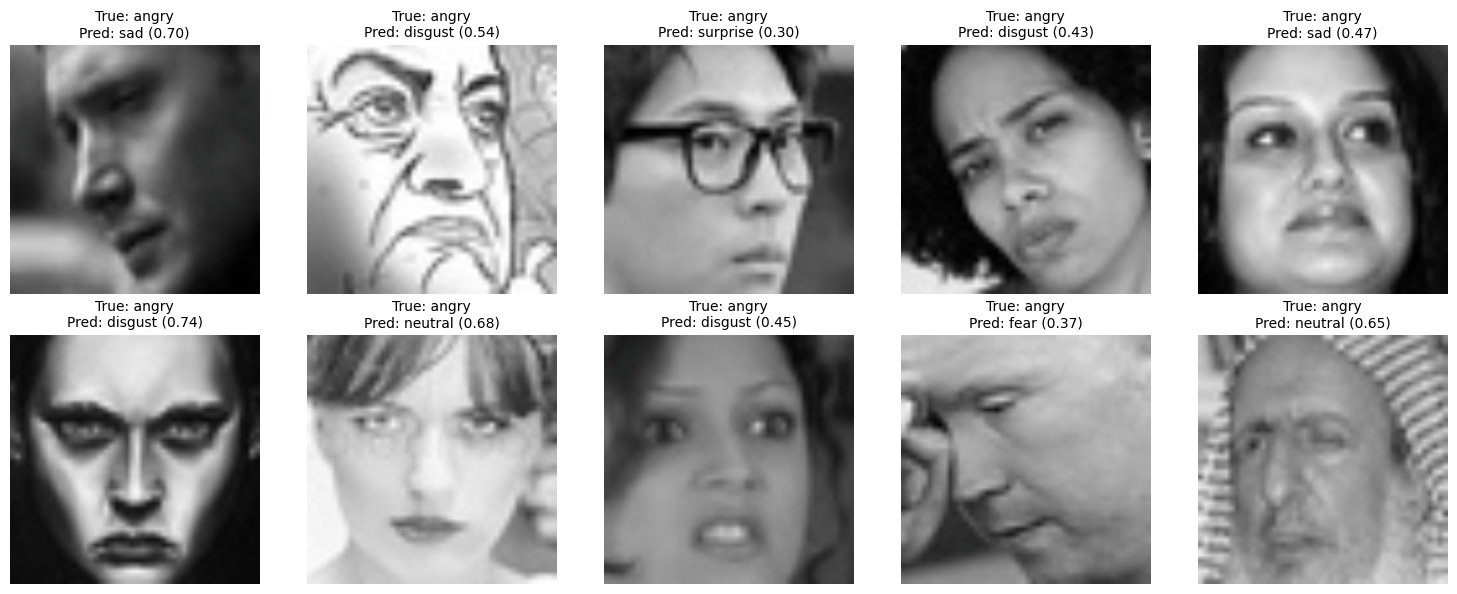

Top confused emotion pairs:
true_label predicted_label  count
       sad         neutral    217
      fear             sad    166
   neutral             sad    152
       sad            fear    130
       sad           angry    118
      fear           angry    109
      fear         neutral    102
      fear        surprise     98
     angry             sad     98
     happy         neutral     94


In [ ]:
def show_misclassified_examples_from_probs(loader, probs, labels, class_names, n=10):
    """Display up to n misclassified images with true label, prediction, and confidence."""
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    wanted_positions = [idx for idx, (y, p) in enumerate(zip(labels, preds)) if y != p][:n]
    wanted_set = set(wanted_positions)

    if not wanted_positions:
        print("No misclassified examples found.")
        return

    collected = []
    offset = 0
    for images, batch_labels in loader:
        batch_size = images.size(0)
        for batch_idx in range(batch_size):
            global_pos = offset + batch_idx
            if global_pos in wanted_set:
                collected.append((global_pos, images[batch_idx].clone()))
        offset += batch_size
        if len(collected) >= len(wanted_positions):
            break

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for ax_idx, ax in enumerate(axes):
        if ax_idx >= len(collected):
            ax.axis('off')
            continue
        pos, image_tensor = collected[ax_idx]
        image = denormalize_imagenet_batch(image_tensor.unsqueeze(0)).squeeze(0)
        image = image.permute(1, 2, 0).clamp(0, 1).numpy()
        true_name = class_names[int(labels[pos])]
        pred_name = class_names[int(preds[pos])]
        ax.imshow(image)
        ax.set_title(f"True: {true_name}\nPred: {pred_name} ({confs[pos]:.2f})", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'cleaned_model_misclassified_examples.png', dpi=150, bbox_inches='tight')
    plt.show()


def summarize_top_confusions(cm, class_names, top_n=10):
    """Return the largest off-diagonal confusion pairs from a confusion matrix."""
    rows = []
    for true_idx in range(cm.shape[0]):
        for pred_idx in range(cm.shape[1]):
            if true_idx == pred_idx:
                continue
            count = int(cm[true_idx, pred_idx])
            if count > 0:
                rows.append({
                    'true_label': class_names[true_idx],
                    'predicted_label': class_names[pred_idx],
                    'count': count,
                })
    if not rows:
        print("No off-diagonal confusions found.")
        return pd.DataFrame(columns=['true_label', 'predicted_label', 'count'])

    confusion_df = pd.DataFrame(rows).sort_values('count', ascending=False).head(top_n)
    print("Top confused emotion pairs:")
    print(confusion_df.to_string(index=False))
    confusion_df.to_csv(METRICS_DIR / 'cleaned_model_top_confusions.csv', index=False)
    return confusion_df


# Prefer cleaned-data ensemble errors if available; otherwise use cleaned ConvNeXt + TTA.
if cleaned_ensemble_probs is not None:
    error_probs = cleaned_ensemble_probs
    error_labels = cleaned_ensemble_labels
    error_cm = cleaned_ensemble_cm
    error_model_name = 'Cleaned-data Ensemble'
else:
    error_probs = cleaned_convnext_tta_probs
    error_labels = cleaned_convnext_tta_labels
    error_cm = cleaned_convnext_tta_cm
    error_model_name = 'Cleaned-data ConvNeXt-Tiny + TTA'

print(f"Error analysis model: {error_model_name}")
show_misclassified_examples_from_probs(
    cleaning_test_loader,
    error_probs,
    error_labels,
    CLASS_NAMES,
    n=10,
)
cleaned_top_confusions_df = summarize_top_confusions(error_cm, CLASS_NAMES, top_n=10)


## Model Comparison

The final comparison table focuses on the project models used for selection: baseline CNN, ResNet-18 fine-tuning, EfficientNet-B0 attempt, ConvNeXt-Tiny, ConvNeXt-Tiny + TTA, the original ResNet-18 + ConvNeXt ensemble, and the cleaned-data runs if those cells have been evaluated. Values are produced from real evaluation cells; no target metrics are hardcoded.


In [ ]:
# Comparison table
comparison_df = pd.DataFrame(all_results).drop_duplicates(subset='model', keep='last')
comparison_df['model'] = comparison_df['model'].replace({
    'EfficientNet-B0 (Best Weighted F1)': 'EfficientNet-B0 Attempt',
    'EfficientNet-B0': 'EfficientNet-B0 Attempt',
})

model_order = [
    'Baseline CNN',
    'ResNet-18 (Fine-Tuning)',
    'EfficientNet-B0 Attempt',
    'ConvNeXt-Tiny',
    'ConvNeXt-Tiny + TTA',
    'ResNet-18 + ConvNeXt-Tiny Ensemble',
    'Cleaned-data ConvNeXt-Tiny',
    'Cleaned-data ConvNeXt-Tiny + TTA',
    'Cleaned-data Ensemble',
]
comparison_df = comparison_df[comparison_df['model'].isin(model_order)].copy()
comparison_df['model_order'] = comparison_df['model'].apply(lambda name: model_order.index(name))
comparison_df = comparison_df.sort_values('model_order').drop(columns='model_order')

col_order = [
    'model',
    'val_acc',
    'val_weighted_f1',
    'accuracy',
    'weighted_f1',
    'macro_f1',
    'precision',
    'recall',
]
comparison_df = comparison_df[[c for c in col_order if c in comparison_df.columns]]
comparison_df = comparison_df.rename(columns={c: c.replace('_', ' ').title() for c in comparison_df.columns})

print()
print('='*92)
print('  Final Model Comparison - FER-2013')
print('='*92)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(METRICS_DIR / 'final_model_comparison.csv', index=False)
print(f"Comparison saved -> {METRICS_DIR / 'final_model_comparison.csv'}")



  Final Model Comparison - FER-2013
                             Model  Val Acc  Val Weighted F1  Accuracy  Weighted F1  Macro F1  Precision  Recall
                      Baseline CNN   0.5723              NaN    0.5754       0.5603    0.5082     0.5745  0.5754
           ResNet-18 (Fine-Tuning)   0.6526              NaN    0.6610       0.6544    0.6359     0.6611  0.6610
           EfficientNet-B0 Attempt   0.5603           0.5634    0.5600       0.5600    0.5026     0.5764  0.5600
                     ConvNeXt-Tiny   0.6578           0.6587    0.6647       0.6642    0.6305     0.6671  0.6647
               ConvNeXt-Tiny + TTA   0.6578           0.6587    0.6675       0.6673    0.6325     0.6704  0.6675
ResNet-18 + ConvNeXt-Tiny Ensemble      NaN              NaN    0.6819       0.6771    0.6561     0.6814  0.6819
        Cleaned-data ConvNeXt-Tiny   0.6677           0.6691    0.6808       0.6806    0.6445     0.6858  0.6808
  Cleaned-data ConvNeXt-Tiny + TTA   0.6677           0.669

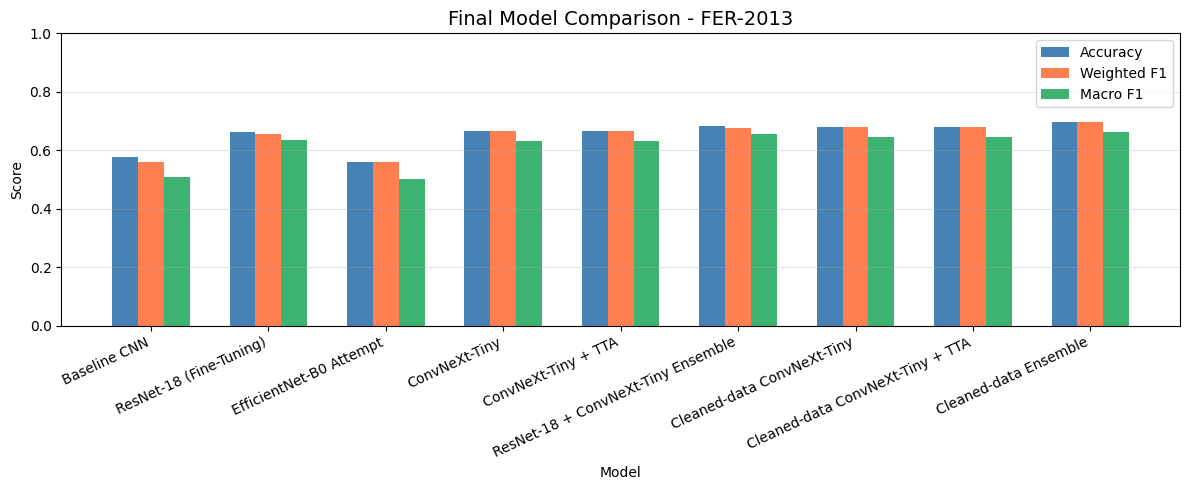

In [ ]:
# Comparison chart
fig, ax = plt.subplots(figsize=(12, 5))

models = comparison_df['Model']
x = np.arange(len(models))
width = 0.22

ax.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x, comparison_df['Weighted F1'], width, label='Weighted F1', color='coral')
ax.bar(x + width, comparison_df['Macro F1'], width, label='Macro F1', color='mediumseagreen')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison - FER-2013', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Final Observations

EfficientNet-B0 was attempted but did not outperform ResNet-18, so it remains an underperforming comparison model. ConvNeXt-Tiny and TTA improved the previous single-model results slightly, and the ResNet-18 + ConvNeXt-Tiny ensemble is currently the strongest observed result at around 68% accuracy.

The final improvement attempt focuses on FERPlus-style cleaning because the main bottleneck is likely noisy FER-2013 labels and ambiguous expressions, not a lack of additional architectures. Removing only high-confidence label disagreements can help, but it may also remove hard-but-valid examples, so the cleaned-data result should be accepted only if its real validation/test metrics improve.

An 80% result should not be claimed unless the notebook actually produces it. If cleaned-data fine-tuning does not improve over the ensemble, the honest conclusion is that label noise and ambiguity still limit performance under this training setup.


## Next Steps for Demo

After selecting the best model from test metrics, save that checkpoint and reuse the same preprocessing pipeline for a Streamlit image-upload/webcam demo. For webcam inference, keep the face crop, grayscale-to-RGB conversion, resize, ImageNet normalization, and any selected TTA policy identical to the final model's evaluation pipeline.


## 15. Contribution Summary

Anirudh Ramesh handled roughly half of the project work. He organized the overall notebook structure, set up the dataset loading and folder discovery, carried out the exploratory analysis including the class distribution charts and sample image grids, built and trained the baseline CNN, and compiled the initial metrics, training curves, and per-class results.

Rohan Marar covered the other half. They implemented the ResNet-18 transfer learning pipeline both the frozen feature-extraction stage and the partial fine-tuning stage ran those experiments, compared the model performances, reviewed the confusion matrices and class-wise F1 scores, and wrote up the final discussion and observations.

Both teammates collaborated throughout on debugging training runs, cross-checking metric values, and reviewing the full notebook before the checkpoint submission.
